In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path('.')
CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
CSV_FILES

c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


[WindowsPath('AnnTemp.csv'),
 WindowsPath('BBBootCISap.csv'),
 WindowsPath('cor_binned_all2annual-corrected.csv'),
 WindowsPath('FFBootCISap.csv'),
 WindowsPath('FSBootCISap.csv'),
 WindowsPath('Human.csv'),
 WindowsPath('Lake_fire_frequency_24nov2023.csv'),
 WindowsPath('M15_depths.csv'),
 WindowsPath('M15_names.csv'),
 WindowsPath('M15_spec.csv'),
 WindowsPath('O15_depths.csv'),
 WindowsPath('O15_names.csv'),
 WindowsPath('O15_spec.csv'),
 WindowsPath('Pollen50Reg.csv'),
 WindowsPath('Regional_pollen_depths.csv'),
 WindowsPath('Regional_pollen_names.csv'),
 WindowsPath('Regional_pollen_spec.csv')]

In [2]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """Read a CSV file with a few separator fallbacks."""
    for kwargs in (
        dict(sep=None, engine='python'),
        dict(sep=';'),
        dict(sep=','),
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except Exception:
            continue
    return pd.read_csv(path, encoding='utf-8', errors='ignore')


def summarize_df(name: str, df: pd.DataFrame) -> None:
    print(f"\n=== {name} ===")
    print(f"shape: {df.shape}")
    display(df.head(3))
    display(pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
    }))


tables = {}
for csv_path in CSV_FILES:
    try:
        tables[csv_path.stem] = read_csv_robust(csv_path)
    except Exception as exc:
        print(f"[skip] {csv_path.name}: {exc}")

print(f"Fichiers CSV charges: {len(tables)}")
list(tables.keys())

Fichiers CSV charges: 17


['AnnTemp',
 'BBBootCISap',
 'cor_binned_all2annual-corrected',
 'FFBootCISap',
 'FSBootCISap',
 'Human',
 'Lake_fire_frequency_24nov2023',
 'M15_depths',
 'M15_names',
 'M15_spec',
 'O15_depths',
 'O15_names',
 'O15_spec',
 'Pollen50Reg',
 'Regional_pollen_depths',
 'Regional_pollen_names',
 'Regional_pollen_spec']

In [3]:
from sklearn.linear_model import LinearRegression


def find_first_matching_column(df: pd.DataFrame, patterns):
    for pattern in patterns:
        matches = [col for col in df.columns if pattern.lower() in str(col).lower()]
        if matches:
            return matches[0]
    return None


def build_analysis_frame(tables):
    time_patterns = ['Age', 'age', 'Year', 'year', 'Time', 'time', 'Date', 'date', 'annee', 'Année']
    target_patterns = ['Mean', 'mean', 'freq', 'frequency', 'fire']

    if 'FFBootCISap' in tables:
        base_name = 'FFBootCISap'
    else:
        base_name = next(
            (
                name
                for name, df in tables.items()
                if find_first_matching_column(df, time_patterns) is not None
                and find_first_matching_column(df, target_patterns) is not None
            ),
            None,
        )

    if base_name is None:
        raise ValueError('No suitable time series table was found for the frequency analysis.')

    base_df = tables[base_name].copy().drop_duplicates().reset_index(drop=True)
    time_col = find_first_matching_column(base_df, time_patterns)
    target_col = find_first_matching_column(base_df, target_patterns)

    if time_col is None:
        raise ValueError(f'No time column found in {base_name}.')
    if target_col is None:
        raise ValueError(f'No target column found in {base_name}.')

    base_df[time_col] = pd.to_numeric(base_df[time_col], errors='coerce')
    base_df[target_col] = pd.to_numeric(base_df[target_col], errors='coerce')
    base_df = base_df.dropna(subset=[time_col, target_col]).sort_values(time_col).reset_index(drop=True)

    merged_frames = []
    for name, df in tables.items():
        df_work = df.copy().drop_duplicates().reset_index(drop=True)
        table_time_col = find_first_matching_column(df_work, time_patterns)
        if table_time_col is None:
            continue

        numeric_cols = df_work.select_dtypes(include=np.number).columns.tolist()
        if table_time_col in numeric_cols:
            numeric_cols.remove(table_time_col)

        if not numeric_cols:
            continue

        temp = df_work[[table_time_col] + numeric_cols].copy()
        temp[table_time_col] = pd.to_numeric(temp[table_time_col], errors='coerce')
        temp = temp.dropna(subset=[table_time_col]).drop_duplicates(subset=[table_time_col]).sort_values(table_time_col)

        if name == base_name:
            temp = temp.rename(columns={table_time_col: time_col})
        else:
            temp = temp.rename(columns={table_time_col: time_col, **{col: f'{name}__{col}' for col in numeric_cols}})

        merged_frames.append(temp)

    if not merged_frames:
        raise ValueError('Unable to build a merged analysis frame from the CSV files.')

    analysis_time = merged_frames[0]
    for temp in merged_frames[1:]:
        analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')

    analysis_time = analysis_time.sort_values(time_col).reset_index(drop=True)
    numeric_analysis_cols = [
        col for col in analysis_time.columns
        if col != time_col and pd.api.types.is_numeric_dtype(analysis_time[col])
    ]
    if numeric_analysis_cols:
        analysis_time[numeric_analysis_cols] = (
            analysis_time[numeric_analysis_cols]
            .interpolate(limit_direction='both')
            .ffill()
            .bfill()
        )

    analysis_df = base_df.copy()
    return analysis_df, analysis_time, time_col, target_col, base_name


def coerce_time_to_numeric(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().any():
        return numeric.astype(float)

    parsed = pd.to_datetime(series, errors='coerce')
    if parsed.notna().any():
        return pd.Series(parsed.view('int64'), index=series.index, dtype='float64')

    return pd.Series(np.arange(len(series)), index=series.index, dtype='float64')


def run_linear_by_period(df, target_col, time_col_name, period_years, test_frac=0.2, min_samples=30):
    if time_col_name not in df.columns or target_col not in df.columns:
        raise ValueError(f'Missing required columns: {time_col_name} and/or {target_col}.')

    work = df[[time_col_name, target_col]].copy()
    work[target_col] = pd.to_numeric(work[target_col], errors='coerce')
    work['_time_numeric'] = coerce_time_to_numeric(work[time_col_name])
    work = work.dropna(subset=['_time_numeric', target_col]).sort_values('_time_numeric').reset_index(drop=True)

    if work.empty:
        return pd.DataFrame(), pd.DataFrame()

    period_offset = work['_time_numeric'].min()
    work['_period_id'] = np.floor((work['_time_numeric'] - period_offset) / float(period_years)).astype(int)

    metrics_rows = []
    preds_rows = []

    for period_id, period_df in work.groupby('_period_id', sort=True):
        period_df = period_df.sort_values('_time_numeric').reset_index(drop=True)
        if len(period_df) < min_samples:
            continue

        split_idx = int(round(len(period_df) * (1 - test_frac)))
        split_idx = max(1, min(split_idx, len(period_df) - 1))
        if split_idx <= 0 or split_idx >= len(period_df):
            continue

        train_df = period_df.iloc[:split_idx].copy()
        test_df = period_df.iloc[split_idx:].copy()
        if train_df.empty or test_df.empty:
            continue

        model = LinearRegression()
        model.fit(train_df[['_time_numeric']], train_df[target_col])
        predictions = model.predict(test_df[['_time_numeric']])

        metrics_rows.append({
            'period_years': period_years,
            'period_id': int(period_id),
            'n_train': len(train_df),
            'n_test': len(test_df),
            'MAE': mean_absolute_error(test_df[target_col], predictions),
            'RMSE': float(np.sqrt(mean_squared_error(test_df[target_col], predictions))),
            'R2': r2_score(test_df[target_col], predictions),
        })

        for time_value, truth_value, pred_value in zip(test_df[time_col_name], test_df[target_col], predictions):
            preds_rows.append({
                time_col_name: time_value,
                target_col: truth_value,
                'pred': pred_value,
                'period_years': period_years,
            })

    metrics_df = pd.DataFrame(metrics_rows)
    preds_df = pd.DataFrame(preds_rows)
    if not metrics_df.empty:
        metrics_df = metrics_df.sort_values(['period_years', 'period_id']).reset_index(drop=True)
    if not preds_df.empty:
        preds_df = preds_df.sort_values([time_col_name, 'period_years']).reset_index(drop=True)
    return metrics_df, preds_df


analysis_df, analysis_time, time_col, candidate_target, source_table_name = build_analysis_frame(tables)
print(f'Analysis table: {source_table_name}')
print(f'Time column: {time_col}')
print(f'Target column: {candidate_target}')
print(f'Analysis rows: {len(analysis_time)} | columns: {len(analysis_time.columns)}')

display(analysis_df.head(3))
display(analysis_time.head(3))


Analysis table: FFBootCISap
Time column: Age
Target column: Mean
Analysis rows: 14263 | columns: 44


C:\Users\lenovo\AppData\Local\Temp\ipykernel_30412\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_30412\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_30412\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_30412\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge

,Age,Mean,CI,Infe,Supe
0,-62,0.00397,0.9,0.002448,0.005514
1,-61,0.00397,0.9,0.002409,0.005545
2,-60,0.00397,0.9,0.002462,0.005588


,Age,AnnTemp__AnnTemp,AnnTemp__Unnamed: 2,AnnTemp__Unnamed: 3,AnnTemp__Unnamed: 4,BBBootCISap__Mean,BBBootCISap__CI,BBBootCISap__Infe,BBBootCISap__Supe,Mean,CI,Infe,Supe,FSBootCISap__Mean,FSBootCISap__CI,FSBootCISap__Infe,FSBootCISap__Supe,Human__human,M15_depths__depths,M15_depths__Depth,M15_depths__Age_OLD,O15_depths__depths,O15_depths__Depth,O15_depths__Age_OLD,Pollen50Reg__Abies,Pollen50Reg__Cupressaceae,Pollen50Reg__Larix,Pollen50Reg__Picea,Pollen50Reg__Pinus,Pollen50Reg__Alnus,Pollen50Reg__Betula,Pollen50Reg__Populus,Pollen50Reg__Quercus,Pollen50Reg__Salix,Pollen50Reg__Ulmus,Pollen50Reg__Ambrosia,Pollen50Reg__Artemisia,Pollen50Reg__Asteraceae,Pollen50Reg__Chenopodium,Pollen50Reg__Cyperaceae,Pollen50Reg__Poaceae,Pollen50Reg__Aquatics,Regional_pollen_depths__depths,Regional_pollen_depths__Depth
0,-62.0,-0.124983,NaN,NaN,NaN,0.023641,0.9,0.008164,0.038994,0.00397,0.9,0.002448,0.005514,0.688920,0.9,0.621528,0.754815,4.528384,570.000000,0.000000,-62.000000,390.000000,0.000000,-62.000000,1.418909,0.710853,1.248406,12.676318,56.014300,3.228284,11.661753,0.385694,1.374823,0.526785,0.294370,1.237380,1.713570,0.558144,0.990300,0.466820,1.461328,1.020428,1.000000,1.000000
1,-61.0,-0.124983,NaN,NaN,NaN,0.023339,0.9,0.009347,0.037836,0.00397,0.9,0.002409,0.005545,0.688738,0.9,0.620918,0.757118,4.528384,570.181818,0.181818,-60.963636,390.140845,0.140845,-60.957746,1.412361,0.714840,1.246453,12.636663,56.063914,3.230229,11.671256,0.386071,1.372305,0.525461,0.292816,1.241068,1.716516,0.557224,0.986683,0.468898,1.467987,1.017756,1.009615,1.961538
2,-60.0,-0.124983,NaN,NaN,NaN,0.023037,0.9,0.010253,0.036165,0.00397,0.9,0.002462,0.005588,0.688555,0.9,0.618522,0.761105,4.528384,570.363636,0.363636,-59.927273,390.281690,0.281690,-59.915493,1.405813,0.718826,1.244500,12.597008,56.113528,3.232174,11.680759,0.386449,1.369787,0.524138,0.291262,1.244755,1.719462,0.556304,0.983067,0.470976,1.474647,1.015085,1.019231,2.923077


In [4]:
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Périphérique utilisé: {device}')

# Configuration pour les modèles séquentiels
SEQ_INPUT_LEN = 192      # Nombre de pas de temps en entrée
SEQ_HORIZON = 48         # Nombre de pas à prédire
VAL_FRACTION = 0.2      # Proportion de validation
BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 1e-3
PRED_STEPS_PER_CALL = 1  # nombre de pas prédits à chaque appel du modèle

# Préparer les données pour la fréquence
freq_source_df = analysis_time.copy() if 'analysis_time' in globals() else None
if freq_source_df is None:
    raise RuntimeError('analysis_time non trouvé. Exécute les cellules précédentes.')

freq_target_col = candidate_target if 'candidate_target' in globals() and candidate_target is not None else None
if freq_target_col is None or freq_target_col not in freq_source_df.columns:
    raise RuntimeError('La cible de fréquence n\'a pas été identifiée.')

# Identifier la colonne de temps
if 'time_value' in freq_source_df.columns:
    freq_time_col = 'time_value'
elif 'time_col' in globals() and time_col in freq_source_df.columns:
    freq_time_col = time_col
else:
    freq_time_col = '__row_order__'
    freq_source_df = freq_source_df.reset_index(drop=True).rename(columns={'index': freq_time_col})

# Nettoyer et trier
freq_source_df = freq_source_df.drop_duplicates().copy()
freq_source_df = freq_source_df.sort_values(freq_time_col).reset_index(drop=True)

# ===== CHANGEMENT PRINCIPAL: Charger UNIQUEMENT temps et mean (univarié) =====
# Sélectionner UNIQUEMENT la colonne temps et la cible (mean)
freq_work = freq_source_df[[freq_time_col, freq_target_col]].copy()
freq_work[freq_target_col] = pd.to_numeric(freq_work[freq_target_col], errors='coerce')

# Imputer les valeurs manquantes
freq_work[freq_target_col] = (
    freq_work[freq_target_col]
    .interpolate(limit_direction='both')
    .ffill()
    .bfill()
)
epsilon = 1e-9
freq_work[freq_target_col] = 1.0 / (freq_work[freq_target_col] + epsilon)

print(f'Mode univarié: Temps + 1/Mean uniquement uniquement')
print(f'Variable cible (transformée 1/Mean): {freq_target_col}')
print(f'Colonne de temps: {freq_time_col}')
print(f'Lignes totales: {len(freq_work)}')
print(f'Data shape: {freq_work.shape}')
display(freq_work.head())

Périphérique utilisé: cpu
Mode univarié: Temps + 1/Mean uniquement uniquement
Variable cible (transformée 1/Mean): Mean
Colonne de temps: Age
Lignes totales: 14263
Data shape: (14263, 2)


,Age,Mean
0,-62.0,251.913853
1,-61.0,251.913853
2,-60.0,251.913853
3,-59.0,251.882063
4,-58.0,251.850344


In [5]:
# Diviser train/validation avec split chronologique
split_row = int(len(freq_work) * (1 - VAL_FRACTION))
train_frame = freq_work.iloc[:split_row].copy()
val_start = max(0, split_row - SEQ_INPUT_LEN - SEQ_HORIZON + 1)
val_frame = freq_work.iloc[val_start:].copy()

# Normaliser les données (univarié)
target_scaler = StandardScaler()
freq_target_scaler = target_scaler

# Extraire les valeurs numériques
train_y = target_scaler.fit_transform(train_frame[[freq_target_col]])
val_y = target_scaler.transform(val_frame[[freq_target_col]])

print(f'Train: {len(train_y)} échantillons | Validation: {len(val_y)} échantillons')


class UnivariateSequenceDataset(Dataset):
    """Dataset pour fenêtres temporelles univariées."""
    def __init__(self, y_array, input_len=SEQ_INPUT_LEN, horizon=SEQ_HORIZON):
        self.y_array = y_array.astype(np.float32).flatten()
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return max(0, len(self.y_array) - self.input_len - self.horizon + 1)

    def __getitem__(self, idx):
        x = self.y_array[idx : idx + self.input_len]
        y = self.y_array[idx + self.input_len : idx + self.input_len + self.horizon]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_ds = UnivariateSequenceDataset(train_y)
val_ds = UnivariateSequenceDataset(val_y)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Fenêtres train: {len(train_ds)} | Fenêtres val: {len(val_ds)}')
print(f'Taille d\'entrée: {SEQ_INPUT_LEN} | Horizon: {SEQ_HORIZON}')

Train: 11410 échantillons | Validation: 3092 échantillons
Fenêtres train: 11171 | Fenêtres val: 2853
Taille d'entrée: 192 | Horizon: 48


In [6]:
class PositionalEncoding(nn.Module):
    """Encodage positionnel pour Transformer."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LSTMPatch(nn.Module):
    """LSTM avec patchs pour séries univariées."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4, 
                 hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = seq_len // patch_size
        
        # Projection du patch vers embedding
        self.patch_embedding = nn.Linear(patch_size, hidden_dim)
        
        # LSTM multi-couches
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Couches de décodage
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape en patchs: (batch, num_patches, patch_size)
        x = x.view(batch_size, self.num_patches, self.patch_size)
        
        # Embedding des patchs
        x = self.patch_embedding(x)  # (batch, num_patches, hidden_dim)
        
        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(x)  # (batch, num_patches, hidden_dim)
        
        # Prendre le dernier état
        x = lstm_out[:, -1, :]  # (batch, hidden_dim)
        
        # Prédiction
        out = self.fc(x)  # (batch, pred_len)
        return out


class TransformerPatch(nn.Module):
    """Transformer avec patchs pour séries univariées."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, patch_size=4,
                 d_model=128, nhead=8, num_layers=3, dropout=0.1, dim_ff=512):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.num_patches = seq_len // patch_size
        
        # Projection du patch vers embedding
        self.patch_embedding = nn.Linear(patch_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Décodeur
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape en patchs
        x = x.view(batch_size, self.num_patches, self.patch_size)
        
        # Embedding et positional encoding
        x = self.patch_embedding(x)  # (batch, num_patches, d_model)
        x = self.pos_encoding(x)
        
        # Transformer
        x = self.transformer_encoder(x)  # (batch, num_patches, d_model)
        
        # Agrégation: moyenne + dernier token
        x = x.mean(dim=1) + x[:, -1, :]  # (batch, d_model)
        
        # Prédiction
        out = self.fc(x)
        return out


class NBeats(nn.Module):
    """N-BEATS: Neural Basis Expansion Analysis (état-de-l'art)."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, 
                 stack_types=['trend', 'seasonality'], num_blocks=3, 
                 hidden_dim=128, num_layers=4):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.stack_types = stack_types
        
        self.stacks = nn.ModuleList()
        for stack_type in stack_types:
            blocks = nn.ModuleList()
            for _ in range(num_blocks):
                blocks.append(self._create_block(hidden_dim, num_layers, stack_type))
            self.stacks.append(blocks)
    
    def _create_block(self, hidden_dim, num_layers, stack_type):
        """Crée un bloc N-BEATS."""
        net = nn.Sequential(
            nn.Linear(self.seq_len, hidden_dim),
            nn.ReLU()
        )
        for _ in range(num_layers - 1):
            net.add_module(f'fc', nn.Linear(hidden_dim, hidden_dim))
            net.add_module(f'relu', nn.ReLU())
        
        # Forecast head
        net.add_module('forecast_head', nn.Linear(hidden_dim, self.pred_len))
        return net
    
    def forward(self, x):
        # x: (batch, seq_len)
        forecast = torch.zeros(x.shape[0], self.pred_len, device=x.device)
        
        for stack in self.stacks:
            for block in stack:
                forecast = forecast + block(x)
        
        return forecast


class TemporalFusionTransformer(nn.Module):
    """Temporal Fusion Transformer simplifié pour univarié."""
    def __init__(self, seq_len=SEQ_INPUT_LEN, pred_len=SEQ_HORIZON, 
                 d_model=128, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        
        # Input processing
        self.input_embed = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        # Static context variable (optionnel, pour cohérence)
        self.static_context = nn.Linear(1, d_model)
        
        # Temporal fusion attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            batch_first=True, dropout=dropout, activation='gelu'
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size = x.shape[0]
        
        # Reshape pour embedding: (batch, seq_len, 1)
        x = x.unsqueeze(-1)
        
        # Embed et add positional encoding
        x = self.input_embed(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        
        # Temporal encoding
        x = self.temporal_encoder(x)  # (batch, seq_len, d_model)
        
        # Agrégation temporelle
        x = x.mean(dim=1)  # (batch, d_model)
        
        # Prédiction
        out = self.decoder(x)
        return out


# Configuration des modèles à tester
MODEL_CONFIGS = [
    ('LSTMPatch', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON, 
        'patch_size': 4, 'hidden_dim': 128, 'num_layers': 2
    }),
    ('TransformerPatch', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'patch_size': 4, 'd_model': 128, 'nhead': 8, 'num_layers': 3
    }),
    ('NBeats', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'num_blocks': 3, 'hidden_dim': 128, 'num_layers': 4
    }),
    ('TemporalFusionTransformer', {
        'seq_len': SEQ_INPUT_LEN, 'pred_len': SEQ_HORIZON,
        'd_model': 128, 'nhead': 8, 'num_layers': 3
    }),
]

print('Modèles configurés: LSTMPatch, TransformerPatch, NBeats, TemporalFusionTransformer')

Modèles configurés: LSTMPatch, TransformerPatch, NBeats, TemporalFusionTransformer


In [7]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Entraîne le modèle pour une époque."""
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
    
    return total_loss / max(1, len(train_loader.dataset))


def validate(model, val_loader, criterion, device):
    """Évalue le modèle sur la validation."""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
    
    return total_loss / max(1, len(val_loader.dataset))


def fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device='cpu'):
    """Boucle d'entraînement complète."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    history = {'epoch': [], 'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if epoch % 2 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')
        
        if patience_counter >= patience:
            print(f'  → Arrêt anticipé à l\'époque {epoch}')
            break
    
    # Restaurer le meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, pd.DataFrame(history)


def predict_all(model, loader, device):
    """Récupère toutes les prédictions du modèle."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    
    preds = np.vstack(preds) if preds else np.empty((0, SEQ_HORIZON))
    trues = np.vstack(trues) if trues else np.empty((0, SEQ_HORIZON))
    return preds, trues


def inverse_normalize(values, scaler):
    """Dénormalise les valeurs."""
    flat = np.asarray(values).reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(np.asarray(values).shape)


def evaluate_model(preds, trues, model_name):
    """Calcule les métriques de performance."""
    if preds.size == 0 or trues.size == 0:
        return None, None
    
    preds_inv = inverse_normalize(preds, target_scaler)
    trues_inv = inverse_normalize(trues, target_scaler)
    
    # Métriques sur le premier pas d'horizon
    first_pred = preds_inv[:, 0]
    first_true = trues_inv[:, 0]
    
    # Métriques sur tous les horizons
    all_pred = preds_inv.reshape(-1)
    all_true = trues_inv.reshape(-1)
    
    metrics = {
        'Model': model_name,
        'MAE_h1': mean_absolute_error(first_true, first_pred),
        'RMSE_h1': float(np.sqrt(mean_squared_error(first_true, first_pred))),
        'R2_h1': r2_score(first_true, first_pred),
        'MAE_all': mean_absolute_error(all_true, all_pred),
        'RMSE_all': float(np.sqrt(mean_squared_error(all_true, all_pred))),
        'R2_all': r2_score(all_true, all_pred),
    }
    
    plot_data = {
        'time_idx': np.arange(len(first_pred)),
        'truth_h1': first_true,
        'pred_h1': first_pred,
    }
    
    return metrics, plot_data

print('Fonctions d\'entraînement et d\'évaluation définies (univarié).')

Fonctions d'entraînement et d'évaluation définies (univarié).


In [8]:
# Entraîner tous les modèles
results_metrics = []
results_plots = {}
training_histories = {}
trained_models = {}

print(f'\n{"="*70}')
print(f'{"ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS (UNIVARIÉ)":^70}')
print(f'{"="*70}\n')

for model_name, model_kwargs in MODEL_CONFIGS:
    print(f'\n>>> {model_name.upper()}')
    print(f'{"-"*70}')
    
    # Créer le modèle dynamiquement
    if model_name == 'LSTMPatch':
        model = LSTMPatch(**model_kwargs)
    elif model_name == 'TransformerPatch':
        model = TransformerPatch(**model_kwargs)
    elif model_name == 'NBeats':
        model = NBeats(**model_kwargs)
    elif model_name == 'TemporalFusionTransformer':
        model = TemporalFusionTransformer(**model_kwargs)
    else:
        print(f'  ⚠ Modèle {model_name} non reconnu.')
        continue
    
    print(f'  Paramètres: {sum(p.numel() for p in model.parameters())}')
    
    # Entraîner
    model, history_df = fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device)
    training_histories[model_name] = history_df
    trained_models[model_name] = model
    
    # Prédire et évaluer
    preds, trues = predict_all(model, val_loader, device)
    metrics, plot_data = evaluate_model(preds, trues, model_name)
    
    if metrics is not None:
        results_metrics.append(metrics)
        results_plots[model_name] = plot_data
        print(f'\n  ✓ Performance (validation):')
        print(f'    RMSE (h+1): {metrics["RMSE_h1"]:.4f}')
        print(f'    MAE (h+1):  {metrics["MAE_h1"]:.4f}')
        print(f'    R² (h+1):   {metrics["R2_h1"]:.4f}')
    else:
        print(f'  ⚠ Aucune prédiction exploitable.')

# Résumé comparatif
results_df = pd.DataFrame(results_metrics).sort_values('RMSE_h1')
print(f'\n\n{"="*70}')
print(f'{"RÉSUMÉ DES PERFORMANCES":^70}')
print(f'{"="*70}\n')
display(results_df)


           ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS (UNIVARIÉ)            


>>> LSTMPATCH
----------------------------------------------------------------------


  Paramètres: 287536
Epoch  1/12 | Train MSE: 0.055110 | Val MSE: 59.592862
Epoch  2/12 | Train MSE: 0.013967 | Val MSE: 55.552343
Epoch  4/12 | Train MSE: 0.010749 | Val MSE: 59.639066
Epoch  6/12 | Train MSE: 0.008199 | Val MSE: 63.516858
Epoch  8/12 | Train MSE: 0.007109 | Val MSE: 58.620487
Epoch 10/12 | Train MSE: 0.007389 | Val MSE: 64.901359
Epoch 12/12 | Train MSE: 0.006315 | Val MSE: 60.666332
  → Arrêt anticipé à l'époque 12

  ✓ Performance (validation):
    RMSE (h+1): 182.9699
    MAE (h+1):  159.6360
    R² (h+1):   -3.1394

>>> TRANSFORMERPATCH
----------------------------------------------------------------------
  Paramètres: 618160
Epoch  1/12 | Train MSE: 0.035181 | Val MSE: 64.521559
Epoch  2/12 | Train MSE: 0.012089 | Val MSE: 86.695282
Epoch  4/12 | Train MSE: 0.009370 | Val MSE: 97.006626
Epoch  6/12 | Train MSE: 0.007276 | Val MSE: 71.990474
Epoch  8/12 | Train MSE: 0.005975 | Val MSE: 75.248719
Epoch 10/12 | Train MSE: 0.005819 | Val MSE: 70.362418
  → Arrêt an

,Model,MAE_h1,RMSE_h1,R2_h1,MAE_all,RMSE_all,R2_all
2,NBeats,1.992934,2.244050,0.999377,1.829083,2.319118,0.999336
0,LSTMPatch,159.636047,182.969890,-3.139389,154.162338,177.710917,-2.900327
1,TransformerPatch,175.023880,198.497629,-3.871779,173.193130,196.792264,-3.782873
3,TemporalFusionTransformer,233.614594,254.239045,-6.992110,232.792816,253.598446,-6.942660


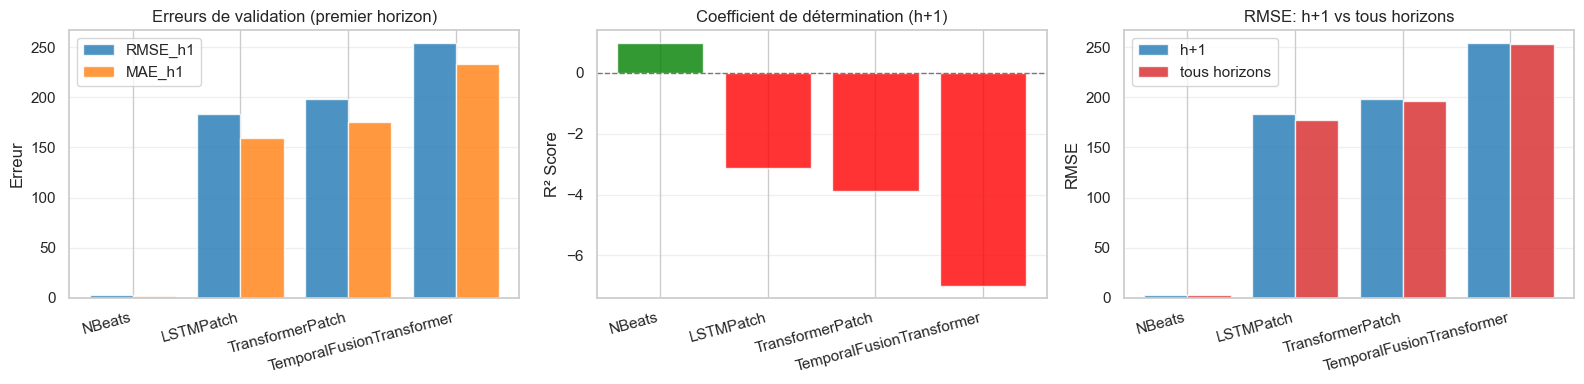

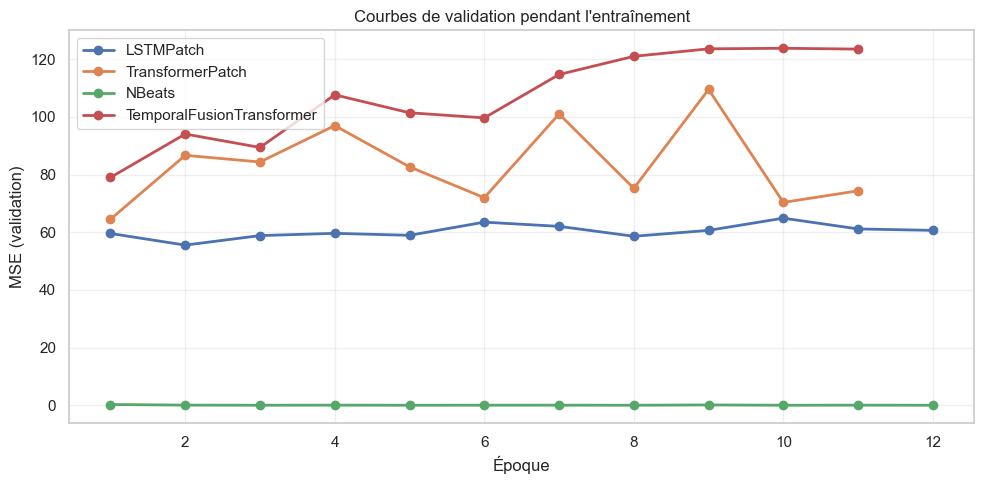

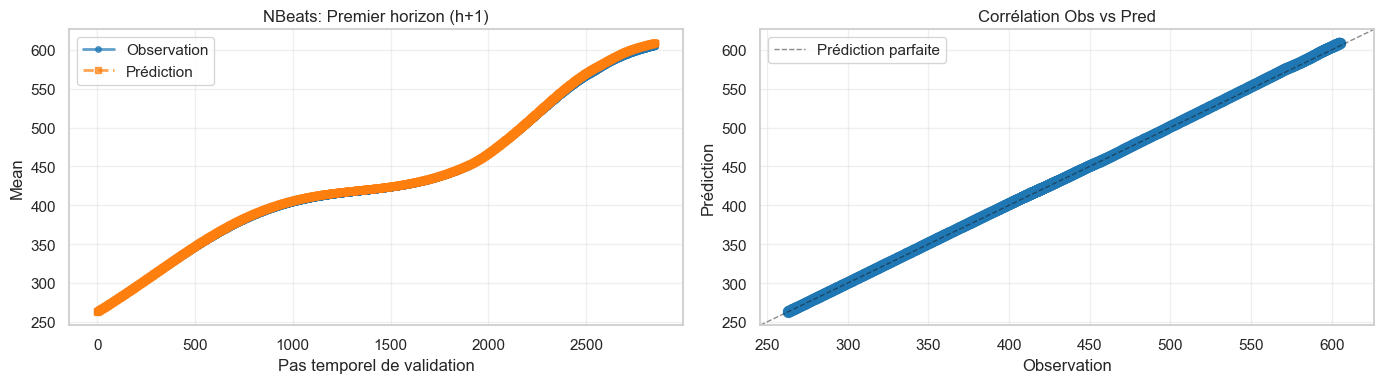

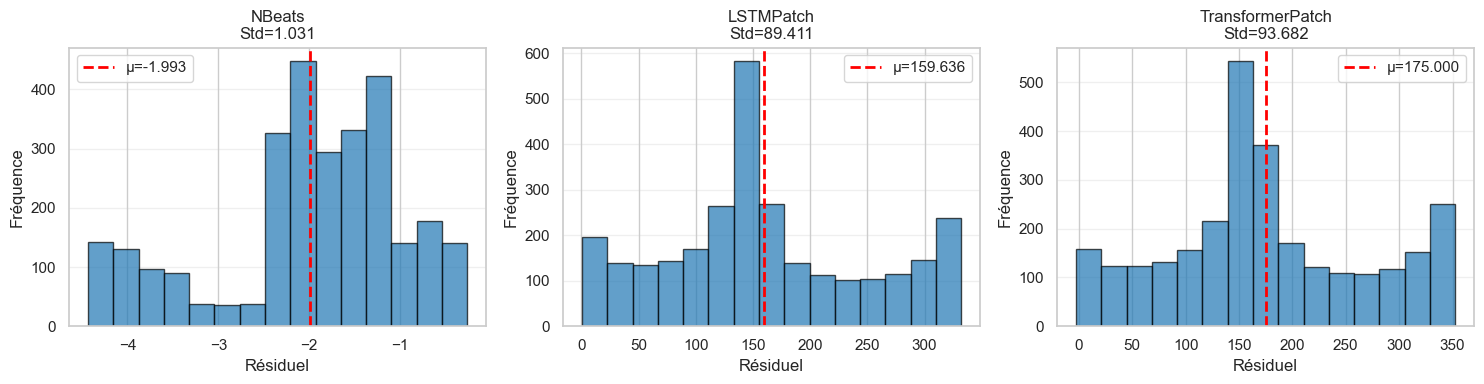


                       MEILLEUR MODÈLE: NBeats                        
 Model   MAE_h1  RMSE_h1    R2_h1  MAE_all  RMSE_all   R2_all
NBeats 1.992934  2.24405 0.999377 1.829083  2.319118 0.999336


In [9]:
if not results_df.empty:
    # === Figure 1: Comparaison des erreurs ===
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Barre RMSE et MAE
    x_pos = np.arange(len(results_df))
    ax = axes[0]
    ax.bar(x_pos - 0.2, results_df['RMSE_h1'], width=0.4, label='RMSE_h1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, results_df['MAE_h1'], width=0.4, label='MAE_h1', alpha=0.8, color='tab:orange')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('Erreur')
    ax.set_title('Erreurs de validation (premier horizon)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # R² comparison
    ax = axes[1]
    colors = ['green' if r2 > 0 else 'red' for r2 in results_df['R2_h1']]
    ax.bar(x_pos, results_df['R2_h1'], alpha=0.8, color=colors)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('R² Score')
    ax.set_title('Coefficient de détermination (h+1)')
    ax.grid(axis='y', alpha=0.3)
    
    # Comparaison multi-horizon
    ax = axes[2]
    x_pos_h = np.arange(len(results_df))
    ax.bar(x_pos_h - 0.2, results_df['RMSE_h1'], width=0.4, label='h+1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos_h + 0.2, results_df['RMSE_all'], width=0.4, label='tous horizons', alpha=0.8, color='tab:red')
    ax.set_xticks(x_pos_h)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE: h+1 vs tous horizons')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === Figure 2: Courbes d'entraînement ===
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, history_df in training_histories.items():
        if not history_df.empty:
            ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label=model_name, linewidth=2)
    ax.set_xlabel('Époque')
    ax.set_ylabel('MSE (validation)')
    ax.set_title('Courbes de validation pendant l\'entraînement')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # === Figure 3: Prédictions vs Observations (meilleur modèle) ===
    best_model_name = results_df.iloc[0]['Model']
    best_plot_data = results_plots[best_model_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Série temporelle complète
    ax = axes[0]
    ax.plot(best_plot_data['time_idx'], best_plot_data['truth_h1'], 'o-', label='Observation', 
            color='tab:blue', alpha=0.7, linewidth=2, markersize=4)
    ax.plot(best_plot_data['time_idx'], best_plot_data['pred_h1'], 's--', label='Prédiction', 
            color='tab:orange', alpha=0.7, linewidth=2, markersize=4)
    ax.fill_between(best_plot_data['time_idx'], best_plot_data['truth_h1'], best_plot_data['pred_h1'], 
                     alpha=0.2, color='gray')
    ax.set_xlabel('Pas temporel de validation')
    ax.set_ylabel(freq_target_col)
    ax.set_title(f'{best_model_name}: Premier horizon (h+1)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Scatter plot
    ax = axes[1]
    ax.scatter(best_plot_data['truth_h1'], best_plot_data['pred_h1'], alpha=0.6, s=50, color='tab:blue')
    
    # Ligne de référence parfaite
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Prédiction parfaite')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prédiction')
    ax.set_title('Corrélation Obs vs Pred')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === Figure 4: Distribution des erreurs ===
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, model_name in enumerate(results_df['Model']):
        if model_name in results_plots:
            plot_data = results_plots[model_name]
            residuals = plot_data['truth_h1'] - plot_data['pred_h1']
            ax = axes[idx] if idx < 3 else None
            if ax is not None:
                ax.hist(residuals, bins=15, alpha=0.7, color='tab:blue', edgecolor='black')
                ax.axvline(x=residuals.mean(), color='red', linestyle='--', linewidth=2, label=f'μ={residuals.mean():.3f}')
                ax.set_xlabel('Résiduel')
                ax.set_ylabel('Fréquence')
                ax.set_title(f'{model_name}\nStd={residuals.std():.3f}')
                ax.legend()
                ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n{"="*70}')
    print(f'{"MEILLEUR MODÈLE: " + best_model_name:^70}')
    print(f'{"="*70}')
    print(results_df[results_df['Model'] == best_model_name].to_string(index=False))
    
else:
    print('⚠ Aucun résultat de modèle séquentiel. Vérifier les données et configurations.')


,model,start_window,input_years,output_years,total_years,MAE_output,RMSE_output,R2_output
0,NBeats,1426,192,48,240,1.150818,1.314516,-7.527094


,position,part,time,actual
0,0,input,11395.0,414.456577
1,1,input,11396.0,414.492137
2,2,input,11397.0,414.527532
3,3,input,11398.0,414.563104
4,4,input,11399.0,414.599542
...,...,...,...,...
235,235,output,11609.0,421.534867
236,236,output,11610.0,421.571653
237,237,output,11611.0,421.609511
238,238,output,11612.0,421.647376


,step_ahead,time,actual,predicted,residual
0,1,11570.0,420.146179,421.781006,-1.634827
1,2,11571.0,420.180420,421.726715,-1.546295
2,3,11572.0,420.214661,421.994659,-1.779999
3,4,11573.0,420.249115,420.484741,-0.235626
4,5,11574.0,420.283386,421.481171,-1.197784
5,6,11574.5,420.300507,421.962891,-1.662384
6,7,11575.0,420.317657,422.060913,-1.743256
7,8,11576.0,420.351929,421.111420,-0.759491
8,9,11577.0,420.386200,420.939362,-0.553162
9,10,11578.0,420.420502,422.079681,-1.659180


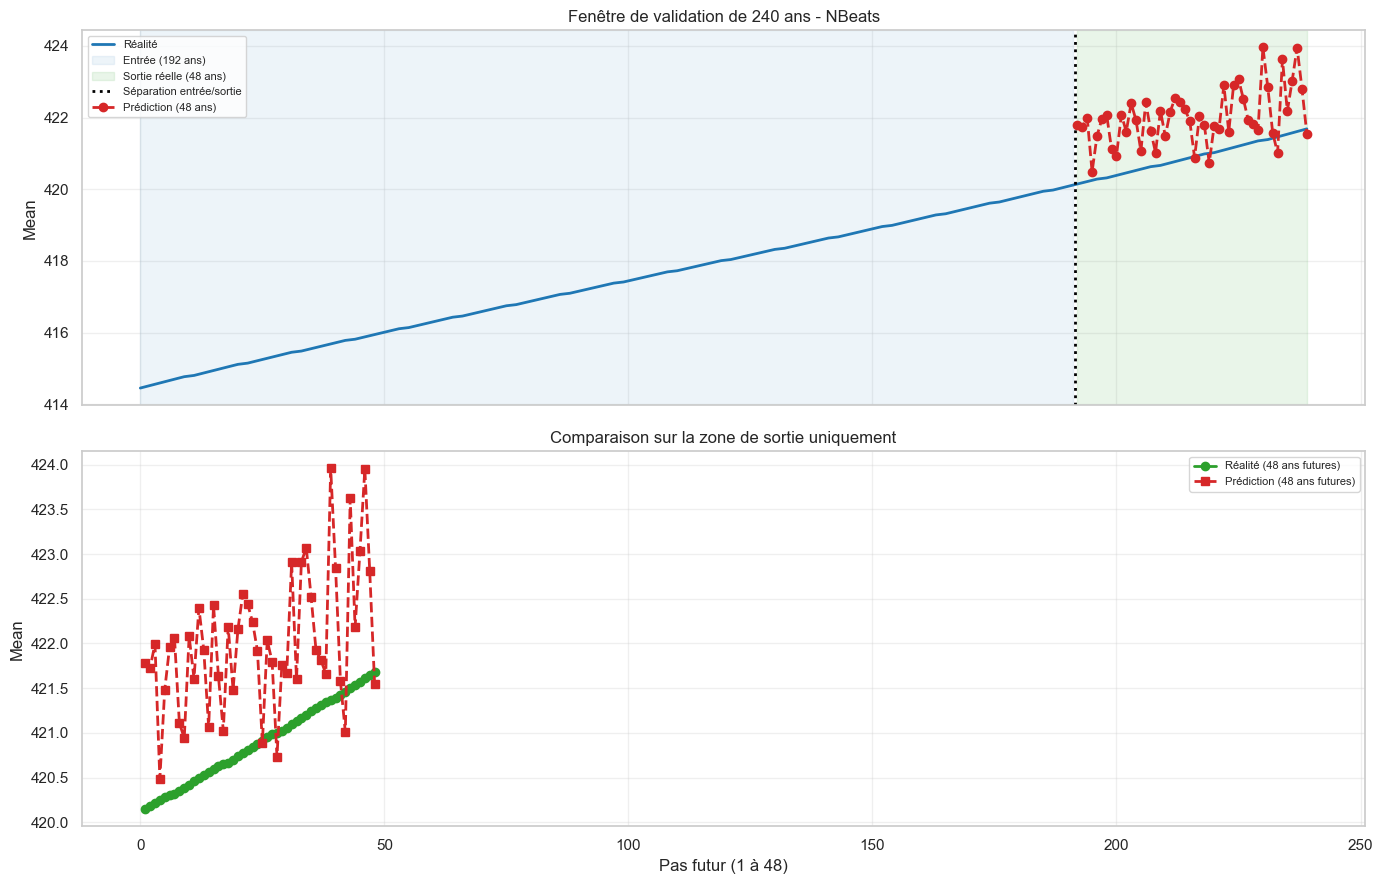

Modèle utilisé: NBeats
Fenêtre choisie: 1426 -> 1665
Entrée: 192 ans | Sortie: 48 ans | Total: 240 ans
MAE sur les 48 années de sortie: 1.1508
RMSE sur les 48 années de sortie: 1.3145


In [10]:
# === FENÊTRE DE VALIDATION DE 240 ANS: 192 ANNÉES D'ENTRÉE + 48 ANNÉES DE SORTIE ===
# But: prendre un segment unique de validation, distinguer la partie entrée (192 ans)
# et la partie sortie (48 ans), puis comparer réalité et prédiction sur ces 240 ans.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)
validation_values = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

# Fenêtre demandée: 192 ans d'entrée + 48 ans de sortie = 240 ans
WINDOW_INPUT = 192  # 24 ans * 8
WINDOW_OUTPUT = 48  # 6 ans * 8
WINDOW_TOTAL = WINDOW_INPUT + WINDOW_OUTPUT

if len(validation_scaled) < WINDOW_TOTAL:
    raise RuntimeError(f"Pas assez de points de validation pour construire une fenêtre de {WINDOW_TOTAL} ans.")

# Choix d'une fenêtre 'quelconque' au milieu de la validation, mais ajustable
START_WINDOW = max(0, min(len(validation_scaled) - WINDOW_TOTAL, len(validation_scaled) // 2 - WINDOW_TOTAL // 2))
END_WINDOW = START_WINDOW + WINDOW_TOTAL

segment_scaled = validation_scaled[START_WINDOW:END_WINDOW]
segment_values = validation_values[START_WINDOW:END_WINDOW]

input_scaled = segment_scaled[:WINDOW_INPUT]
true_future_scaled = segment_scaled[WINDOW_INPUT:WINDOW_TOTAL]

x_tensor = torch.tensor(input_scaled, dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    pred_horizon_scaled = best_model(x_tensor).detach().cpu().numpy().reshape(-1)

if len(pred_horizon_scaled) < WINDOW_OUTPUT:
    raise RuntimeError("Le modèle ne renvoie pas assez de pas pour couvrir WINDOW_OUTPUT. Vérifie que SEQ_HORIZON est bien aligné avec la fenêtre de sortie.")
pred_horizon_scaled = pred_horizon_scaled[:WINDOW_OUTPUT]

# Revenir à l'échelle originale
segment_input = target_scaler.inverse_transform(input_scaled.reshape(-1, 1)).reshape(-1)
segment_future_true = target_scaler.inverse_transform(true_future_scaled.reshape(-1, 1)).reshape(-1)
segment_future_pred = target_scaler.inverse_transform(pred_horizon_scaled.reshape(-1, 1)).reshape(-1)

# Date / index pour l'axe X
if 'freq_time_col' in globals() and freq_time_col in val_frame.columns:
    seg_time = val_frame[freq_time_col].iloc[START_WINDOW:END_WINDOW].reset_index(drop=True)
else:
    seg_time = np.arange(START_WINDOW, END_WINDOW)

comparison_segment_df = pd.DataFrame({
    'position': np.arange(WINDOW_TOTAL),
    'part': ['input'] * WINDOW_INPUT + ['output'] * WINDOW_OUTPUT,
    'time': seg_time,
    'actual': segment_values,
})
comparison_future_df = pd.DataFrame({
    'step_ahead': np.arange(1, WINDOW_OUTPUT + 1),
    'time': seg_time.iloc[WINDOW_INPUT:].reset_index(drop=True) if hasattr(seg_time, 'iloc') else seg_time[WINDOW_INPUT:],
    'actual': segment_future_true,
    'predicted': segment_future_pred,
    'residual': segment_future_true - segment_future_pred,
})

segment_mae = mean_absolute_error(segment_future_true, segment_future_pred)
segment_rmse = float(np.sqrt(mean_squared_error(segment_future_true, segment_future_pred)))
segment_r2 = r2_score(segment_future_true, segment_future_pred) if len(segment_future_true) > 1 else np.nan

summary_segment = pd.DataFrame([
    {
        'model': best_model_name,
        'start_window': START_WINDOW,
        'input_years': WINDOW_INPUT,
        'output_years': WINDOW_OUTPUT,
        'total_years': WINDOW_TOTAL,
        'MAE_output': segment_mae,
        'RMSE_output': segment_rmse,
        'R2_output': segment_r2,
    }
])

display(summary_segment)
display(comparison_segment_df)
display(comparison_future_df)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Courbe sur 240 ans, avec séparation entrée / sortie
ax = axes[0]
ax.plot(comparison_segment_df['position'], comparison_segment_df['actual'], color='tab:blue', linewidth=2, label='Réalité')
ax.axvspan(0, WINDOW_INPUT - 1, color='tab:blue', alpha=0.08, label='Entrée (192 ans)')
ax.axvspan(WINDOW_INPUT, WINDOW_TOTAL - 1, color='tab:green', alpha=0.10, label='Sortie réelle (48 ans)')
ax.axvline(WINDOW_INPUT - 0.5, color='black', linestyle=':', linewidth=2, label='Séparation entrée/sortie')
ax.plot(np.arange(WINDOW_INPUT, WINDOW_TOTAL), segment_future_pred, color='tab:red', linestyle='--', marker='o', linewidth=2, label='Prédiction (48 ans)')
ax.set_title(f"Fenêtre de validation de 240 ans - {best_model_name}")
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# Zoom sur les 48 années de sortie: réalité vs prédiction
ax = axes[1]
ax.plot(np.arange(1, WINDOW_OUTPUT + 1), segment_future_true, color='tab:green', linewidth=2, marker='o', label='Réalité (48 ans futures)')
ax.plot(np.arange(1, WINDOW_OUTPUT + 1), segment_future_pred, color='tab:red', linewidth=2, marker='s', linestyle='--', label='Prédiction (48 ans futures)')
ax.set_xlabel('Pas futur (1 à 48)')
ax.set_ylabel(freq_target_col)
ax.set_title('Comparaison sur la zone de sortie uniquement')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Fenêtre choisie: {START_WINDOW} -> {END_WINDOW - 1}")
print(f"Entrée: {WINDOW_INPUT} ans | Sortie: {WINDOW_OUTPUT} ans | Total: {WINDOW_TOTAL} ans")
print(f"MAE sur les 48 années de sortie: {segment_mae:.4f}")
print(f"RMSE sur les 48 années de sortie: {segment_rmse:.4f}")

,step,predicted_future,model
0,3092,611.689924,NBeats
1,3093,611.826310,NBeats
2,3094,611.935976,NBeats
3,3095,612.078976,NBeats
4,3096,612.206441,NBeats
5,3097,612.344654,NBeats
6,3098,612.483216,NBeats
7,3099,612.614902,NBeats
8,3100,612.745065,NBeats
9,3101,612.863565,NBeats


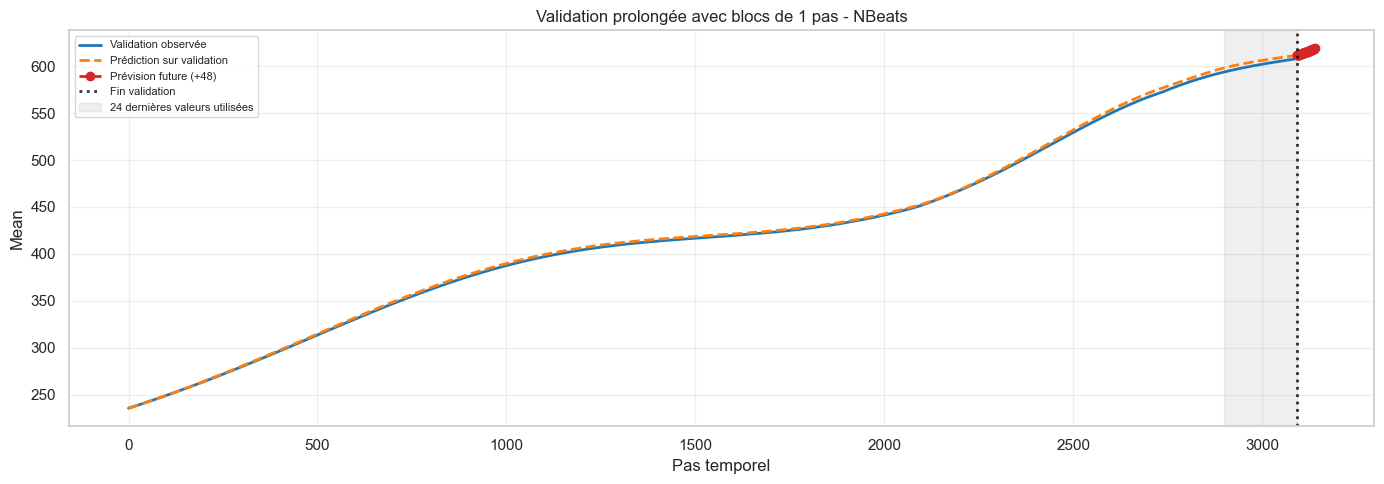

Modèle utilisé: NBeats
Les 48 années futures sont prédites par blocs de 1 pas à partir des 192 dernières valeurs de validation.


In [11]:
# === EXTENSION DE LA COURBE: PRÉDICTION PAR BLOCS DE 5, 10, ... PAS ===
# Cette cellule prend les dernières valeurs observées de la validation,
# prédit plusieurs pas d'un coup, puis répète l'opération pour prolonger la courbe.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_original = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)
validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)

if len(validation_scaled) < SEQ_INPUT_LEN:
    raise RuntimeError(f"Pas assez de points de validation pour utiliser les {SEQ_INPUT_LEN} dernières valeurs.")

# 1) Courbe observée sur toute la validation
validation_steps = np.arange(len(validation_original))

# 2) Prédiction par blocs: on peut demander 5, 10, ... pas à la fois
#    tant que la taille du bloc reste <= SEQ_HORIZON du modèle.
# PRED_STEPS_PER_CALL est défini dans la cellule de configuration


def predict_chunk(model, window_scaled, n_steps):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        full_pred = model(x_tensor).detach().cpu().numpy().reshape(-1)
    return full_pred[:n_steps]


predicted_validation_scaled = validation_scaled[:SEQ_INPUT_LEN].tolist()
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
cursor = SEQ_INPUT_LEN
while cursor < len(validation_scaled):
    chunk_size = min(PRED_STEPS_PER_CALL, SEQ_HORIZON, len(validation_scaled) - cursor)
    chunk_pred = predict_chunk(best_model, history[-SEQ_INPUT_LEN:], chunk_size)
    predicted_validation_scaled.extend(chunk_pred.tolist())
    history.extend(validation_scaled[cursor:cursor + chunk_size].tolist())
    cursor += chunk_size

predicted_validation = target_scaler.inverse_transform(np.asarray(predicted_validation_scaled).reshape(-1, 1)).reshape(-1)

# 3) Extension future à partir des dernières valeurs observées de validation
future_horizon = 48
future_history = validation_scaled[-SEQ_INPUT_LEN:].tolist()
future_pred_scaled = []
while len(future_pred_scaled) < future_horizon:
    chunk_size = min(PRED_STEPS_PER_CALL, SEQ_HORIZON, future_horizon - len(future_pred_scaled))
    next_chunk = predict_chunk(best_model, future_history[-SEQ_INPUT_LEN:], chunk_size)
    future_pred_scaled.extend(next_chunk.tolist())
    # Pour la projection future, on réinjecte les prédictions du modèle.
    future_history.extend(next_chunk.tolist())

future_pred = target_scaler.inverse_transform(np.asarray(future_pred_scaled).reshape(-1, 1)).reshape(-1)
future_steps = np.arange(len(validation_original), len(validation_original) + future_horizon)

# Aucune vraie valeur future n'existe ici: on affiche seulement la prolongation prédite
forecast_extension_df = pd.DataFrame({
    'step': future_steps,
    'predicted_future': future_pred,
    'model': best_model_name,
})

display(forecast_extension_df)

# Graphique: validation observée + courbe prédite prolongée
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(validation_steps, validation_original, color='tab:blue', linewidth=2, label='Validation observée')
ax.plot(validation_steps, predicted_validation, color='tab:orange', linewidth=2, linestyle='--', label='Prédiction sur validation')
ax.plot(future_steps, future_pred, color='tab:red', linewidth=2, linestyle='--', marker='o', label='Prévision future (+48)')
ax.axvline(len(validation_original) - 1, color='black', linestyle=':', linewidth=2, alpha=0.8, label='Fin validation')
ax.axvspan(len(validation_original) - SEQ_INPUT_LEN, len(validation_original) - 1, color='tab:gray', alpha=0.12, label='24 dernières valeurs utilisées')
ax.set_title(f"Validation prolongée avec blocs de {PRED_STEPS_PER_CALL} pas - {best_model_name}")
ax.set_xlabel('Pas temporel')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Les {future_horizon} années futures sont prédites par blocs de {PRED_STEPS_PER_CALL} pas à partir des {SEQ_INPUT_LEN} dernières valeurs de validation.")

,model,n_forecastable_points,MAE_direct,RMSE_direct,MAE_recursive,RMSE_recursive
0,NBeats,800,1.35245,1.485757,49.888877,71.664592


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
0,192,10274.0,262.871296,263.135016,263.135016,-0.263720,-0.263720
1,193,10274.5,262.955488,263.292546,263.298018,-0.337058,-0.342530
2,194,10275.0,263.039735,263.449347,263.460107,-0.409613,-0.420372
3,195,10276.0,263.208389,263.605044,263.624731,-0.396655,-0.416341
4,196,10277.0,263.377191,263.758783,263.786537,-0.381592,-0.409346
5,197,10278.0,263.546279,263.911031,263.947739,-0.364752,-0.401460
6,198,10279.0,263.715167,264.064873,264.110518,-0.349707,-0.395352
7,199,10280.0,263.884828,264.219395,264.273173,-0.334567,-0.388345
8,200,10281.0,264.053592,264.376392,264.438449,-0.322800,-0.384857
9,201,10282.0,264.222573,264.532329,264.600222,-0.309756,-0.377650


,step,time,truth,pred_direct,pred_recursive,residual_direct,residual_recursive
790,982,10992.0,385.650857,387.828210,563.227774,-2.177352,-177.576917
791,983,10993.0,385.770322,387.938049,563.992083,-2.167728,-178.221761
792,984,10994.0,385.889860,388.048150,564.757959,-2.158290,-178.868098
793,985,10994.5,385.949732,388.157925,565.525445,-2.208193,-179.575713
794,986,10995.0,386.009622,388.268657,566.294584,-2.259035,-180.284962
795,987,10996.0,386.129309,388.378671,567.065247,-2.249362,-180.935938
796,988,10997.0,386.249070,388.486226,567.837607,-2.237156,-181.588537
797,989,10998.0,386.368905,388.592976,568.611534,-2.224071,-182.242628
798,990,10999.0,386.487919,388.700531,569.387070,-2.212612,-182.899152
799,991,11000.0,386.605062,388.808064,570.164348,-2.203002,-183.559285


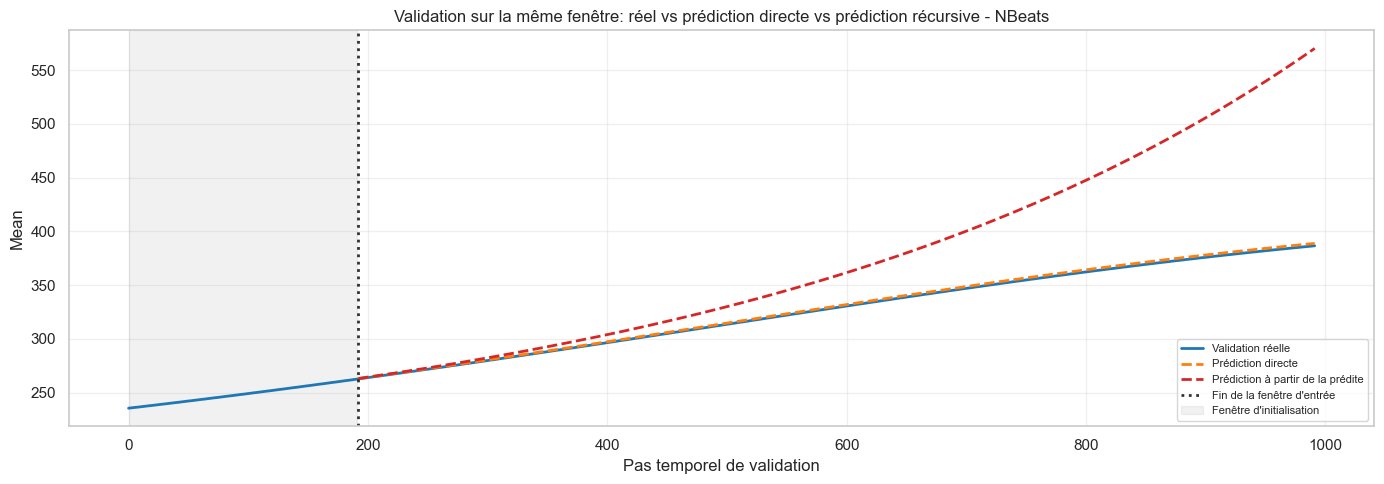

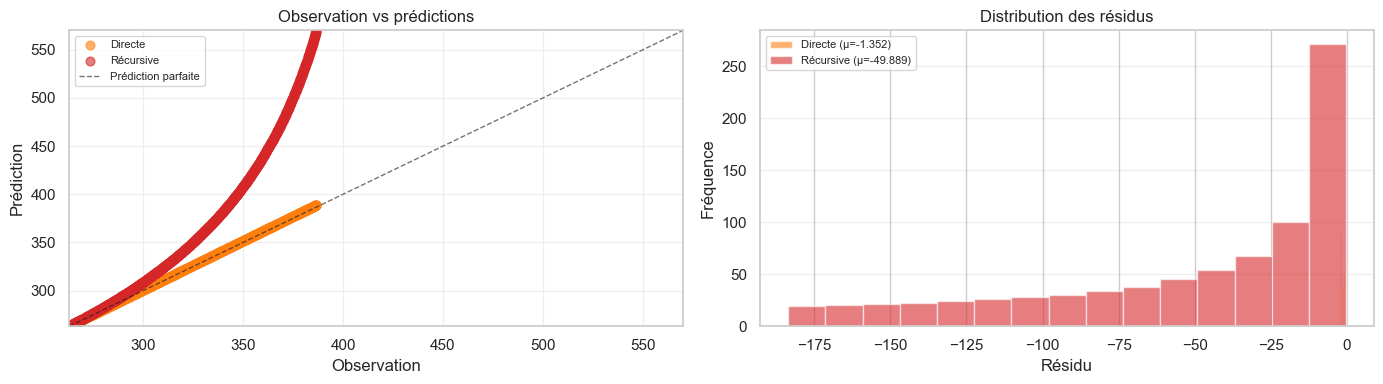

Modèle utilisé: NBeats
Nombre de points comparables sur la fenêtre: 800
La courbe récursive reste dans la même fenêtre temporelle: elle n'est pas prolongée au-delà de la validation.


In [12]:
# === COMPARAISON SUR LA MEME FENETRE: REEL, PREVISION DIRECTE, PREVISION A PARTIR DE LA PREVISION ===
# Objectif: afficher les trois courbes sur la meme fenetre de validation,
# sans prolonger la courbe au-dela de la validation.

# - courbe reel: toute la validation,
# - courbe predite directe: chaque point futur est predit en utilisant les vraies valeurs precedentes,
# - courbe predite a partir de la predite: meme fenetre, mais les predictions sont re-injectees dans l'entree.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

freq_scaler = globals().get('freq_target_scaler', None)
if freq_scaler is None:
    if 'train_frame' not in globals():
        raise RuntimeError("freq_target_scaler est manquant et train_frame n'est pas disponible pour le reconstruire.")
    freq_scaler = StandardScaler()
    freq_scaler.fit(train_frame[[freq_target_col]])

validation_original = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)
validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else freq_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)

if len(validation_scaled) < SEQ_INPUT_LEN + 2:
    raise RuntimeError(f"Pas assez de points de validation pour comparer sur la même fenêtre (SEQ_INPUT_LEN={SEQ_INPUT_LEN}).")

def predict_first_horizon(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return float(model(x_tensor).detach().cpu().numpy().reshape(-1)[0])

forecast_steps = np.arange(SEQ_INPUT_LEN, min(SEQ_INPUT_LEN + 800, len(validation_scaled)))
if len(forecast_steps) == 0:
    raise RuntimeError("La validation est trop courte pour produire une comparaison utile.")

# 1) Prédiction directe: à chaque pas, on utilise les vraies valeurs précédentes
pred_direct_scaled = []
for step in forecast_steps:
    window = validation_scaled[step - SEQ_INPUT_LEN:step]
    pred_direct_scaled.append(predict_first_horizon(best_model, window))

# 2) Prédiction à partir de la prédiction: la sortie précédente est réinjectée dans l'entrée
pred_recursive_scaled = []
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
for _ in forecast_steps:
    window = history[-SEQ_INPUT_LEN:]
    next_pred = predict_first_horizon(best_model, window)
    pred_recursive_scaled.append(next_pred)
    history.append(next_pred)

# Retour à l'échelle originale
truth_window = validation_original[forecast_steps]
pred_direct = freq_scaler.inverse_transform(np.asarray(pred_direct_scaled).reshape(-1, 1)).reshape(-1)
pred_recursive = freq_scaler.inverse_transform(np.asarray(pred_recursive_scaled).reshape(-1, 1)).reshape(-1)

# Axe de temps si disponible, sinon index relatif
if 'freq_time_col' in globals() and freq_time_col in val_frame.columns:
    time_axis = val_frame[freq_time_col].iloc[forecast_steps].reset_index(drop=True)
else:
    time_axis = pd.Series(forecast_steps)

comparison_same_window_df = pd.DataFrame({
    'step': forecast_steps,
    'time': time_axis,
    'truth': truth_window,
    'pred_direct': pred_direct,
    'pred_recursive': pred_recursive,
})
comparison_same_window_df['residual_direct'] = comparison_same_window_df['truth'] - comparison_same_window_df['pred_direct']
comparison_same_window_df['residual_recursive'] = comparison_same_window_df['truth'] - comparison_same_window_df['pred_recursive']

summary_same_window = pd.DataFrame([
    {
        'model': best_model_name,
        'n_forecastable_points': len(comparison_same_window_df),
        'MAE_direct': mean_absolute_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct']),
        'RMSE_direct': float(np.sqrt(mean_squared_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct']))),
        'MAE_recursive': mean_absolute_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive']),
        'RMSE_recursive': float(np.sqrt(mean_squared_error(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive']))),
    }
])

display(summary_same_window)
display(comparison_same_window_df.head(10))
display(comparison_same_window_df.tail(10))

fig, ax = plt.subplots(figsize=(14, 5))
max_plot_idx = SEQ_INPUT_LEN + len(comparison_same_window_df)
ax.plot(np.arange(max_plot_idx), validation_original[:max_plot_idx], color='tab:blue', linewidth=2, label='Validation réelle')
ax.plot(comparison_same_window_df['step'], comparison_same_window_df['pred_direct'], color='tab:orange', linewidth=2, linestyle='--', label='Prédiction directe')
ax.plot(comparison_same_window_df['step'], comparison_same_window_df['pred_recursive'], color='tab:red', linewidth=2, linestyle='--', label='Prédiction à partir de la prédite')
ax.axvline(SEQ_INPUT_LEN - 0.5, color='black', linestyle=':', linewidth=2, alpha=0.8, label='Fin de la fenêtre d\'entrée')
ax.axvspan(0, SEQ_INPUT_LEN - 1, color='tab:gray', alpha=0.10, label='Fenêtre d\'initialisation')
ax.set_title(f"Validation sur la même fenêtre: réel vs prédiction directe vs prédiction récursive - {best_model_name}")
ax.set_xlabel('Pas temporel de validation')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(comparison_same_window_df['truth'], comparison_same_window_df['pred_direct'], alpha=0.6, s=40, color='tab:orange', label='Directe')
ax.scatter(comparison_same_window_df['truth'], comparison_same_window_df['pred_recursive'], alpha=0.6, s=40, color='tab:red', label='Récursive')
lims = [
    np.nanmin([comparison_same_window_df['truth'].min(), comparison_same_window_df['pred_direct'].min(), comparison_same_window_df['pred_recursive'].min()]),
    np.nanmax([comparison_same_window_df['truth'].max(), comparison_same_window_df['pred_direct'].max(), comparison_same_window_df['pred_recursive'].max()]),
]
ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=1, label='Prédiction parfaite')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Observation vs prédictions')
ax.set_xlabel('Observation')
ax.set_ylabel('Prédiction')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
residual_direct = comparison_same_window_df['residual_direct']
residual_recursive = comparison_same_window_df['residual_recursive']
ax.hist(residual_direct, bins=15, alpha=0.6, color='tab:orange', label=f'Directe (μ={residual_direct.mean():.3f})')
ax.hist(residual_recursive, bins=15, alpha=0.6, color='tab:red', label=f'Récursive (μ={residual_recursive.mean():.3f})')
ax.set_title('Distribution des résidus')
ax.set_xlabel('Résidu')
ax.set_ylabel('Fréquence')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Nombre de points comparables sur la fenêtre: {len(comparison_same_window_df)}")
print("La courbe récursive reste dans la même fenêtre temporelle: elle n'est pas prolongée au-delà de la validation.")

,model,n_validation_windows,reference_window,control_window,baseline_mae,baseline_rmse,acceptable_factor,last_acceptable_step,last_acceptable_percent
0,NBeats,1000,20,20,0.432132,0.438473,10,162,16.22


,step,truth_scaled,pred_scaled,truth,pred,abs_error,sq_error,rolling_mae,rolling_rmse,acceptable
0,0,3.473585,3.485143,262.871307,263.135016,0.263708,0.069542,NaN,NaN,False
1,1,3.477275,3.492287,262.955505,263.298018,0.342513,0.117315,NaN,NaN,False
2,2,3.480967,3.499392,263.039734,263.460107,0.420373,0.176713,NaN,NaN,False
3,3,3.488359,3.506607,263.208405,263.624731,0.416326,0.173327,NaN,NaN,False
4,4,3.495757,3.513699,263.377197,263.786537,0.409339,0.167559,NaN,NaN,False
5,5,3.503168,3.520764,263.546295,263.947739,0.401443,0.161157,NaN,NaN,False
6,6,3.510571,3.527898,263.715179,264.110518,0.395339,0.156293,NaN,NaN,False
7,7,3.518007,3.535027,263.884827,264.273173,0.388346,0.150813,NaN,NaN,False
8,8,3.525403,3.542271,264.053589,264.438449,0.384860,0.148117,NaN,NaN,False
9,9,3.532809,3.549361,264.222565,264.600222,0.377658,0.142625,NaN,NaN,False


,step,truth_scaled,pred_scaled,truth,pred,abs_error,sq_error,rolling_mae,rolling_rmse,acceptable
990,990,9.620476,24.951927,403.119019,752.922003,349.802984,122362.127759,339.584427,339.640426,False
991,991,9.622071,25.002899,403.155396,754.084982,350.929586,123151.574373,340.655248,340.711390,False
992,992,9.623668,25.053980,403.191833,755.250441,352.058607,123945.263056,341.730537,341.786858,False
993,993,9.626853,25.105165,403.264496,756.418294,353.153798,124717.604974,342.808475,342.864948,False
994,994,9.630039,25.156460,403.337219,757.588627,354.251408,125494.059993,343.889067,343.945667,False
995,995,9.633234,25.207863,403.410095,758.761441,355.351346,126274.578979,344.972208,345.028911,False
996,996,9.636423,25.259377,403.482849,759.936779,356.453930,127059.404126,346.057890,346.114672,False
997,997,9.639527,25.310997,403.553680,761.114554,357.560874,127849.778300,347.146205,347.203046,False
998,998,9.642612,25.362726,403.624054,762.294809,358.670756,128644.710876,348.237187,348.294067,False
999,999,9.645690,25.414560,403.694305,763.477458,359.783153,129443.917239,349.330842,349.387740,False


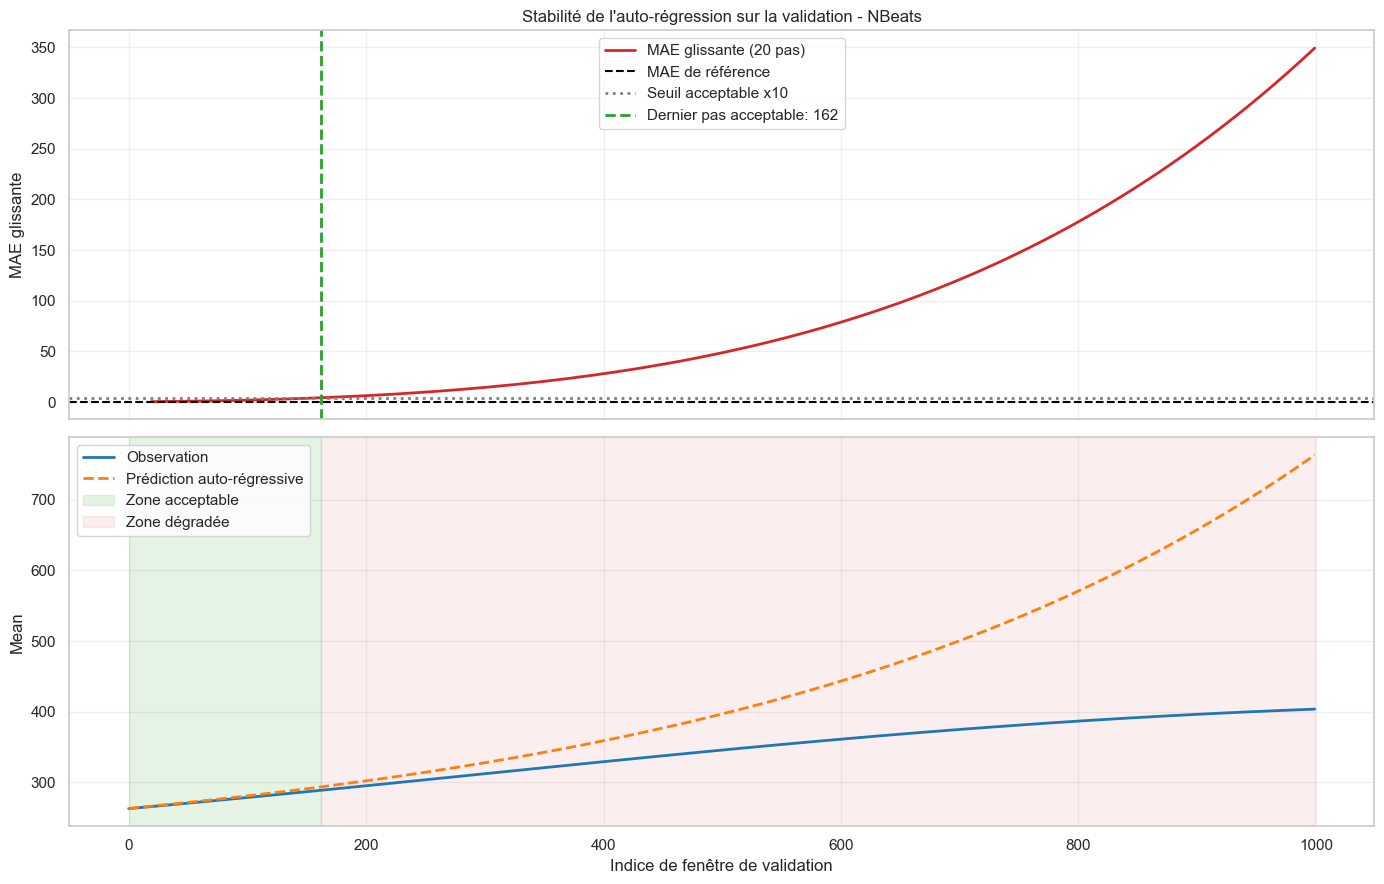

Dernier pas jugé acceptable: 162 sur 999
Cela correspond approximativement à 16.2% de la validation.
Référence: MAE=0.4321, seuil=4.3213


In [13]:
# === JUSQU'OÙ L'AUTO-RÉGRESSION RESTE ACCEPTABLE SUR LA VALIDATION ? ===
# Objectif: parcourir la validation du début à la fin et repérer le point où
# la prédiction auto-régressive commence à se dégrader de façon notable.
#
# Définition de l'acceptabilité ci-dessous:
# - on calcule une erreur absolue glissante sur une fenêtre de contrôle,
# - on compare cette erreur à une référence issue du segment initial normal,
# - on repère le dernier pas où l'erreur reste sous un seuil relatif.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun résultat de modèle trouvé. Exécute d'abord l'entraînement des modèles séquentiels.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'freq_work' not in globals() or 'freq_target_col' not in globals() or 'target_scaler' not in globals():
    raise RuntimeError("Variables fréquence manquantes. Exécute d'abord la préparation des données fréquence.")
if 'val_frame' not in globals():
    raise RuntimeError("val_frame est manquant. Exécute d'abord le split train/validation.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

validation_scaled = np.asarray(
    val_y if 'val_y' in globals() else target_scaler.transform(val_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)
validation_values = pd.to_numeric(val_frame[freq_target_col], errors='coerce').interpolate(limit_direction='both').ffill().bfill().values.astype(float)

if len(validation_scaled) < SEQ_INPUT_LEN + SEQ_HORIZON + 5:
    raise RuntimeError("Pas assez de points de validation pour analyser correctement l'auto-régression.")

n_windows = len(validation_scaled) - SEQ_INPUT_LEN - SEQ_HORIZON + 1
n_windows = min(1000, n_windows)
if n_windows <= 3:
    raise RuntimeError("Validation trop courte pour une analyse de stabilité auto-régressive.")

def predict_h1(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return float(model(x_tensor).detach().cpu().numpy().reshape(-1)[0])

# Générer la prédiction auto-régressive complète sur toute la validation (h+1)
history = validation_scaled[:SEQ_INPUT_LEN].tolist()
ar_truth_scaled = []
ar_pred_scaled = []
for step in range(n_windows):
    truth_idx = step + SEQ_INPUT_LEN
    ar_truth_scaled.append(validation_scaled[truth_idx])
    pred_value = predict_h1(best_model, history[-SEQ_INPUT_LEN:])
    ar_pred_scaled.append(pred_value)
    history.append(pred_value)

ar_df = pd.DataFrame({
    'step': np.arange(n_windows),
    'truth_scaled': ar_truth_scaled,
    'pred_scaled': ar_pred_scaled,
})
ar_df['truth'] = target_scaler.inverse_transform(ar_df[['truth_scaled']]).reshape(-1)
ar_df['pred'] = target_scaler.inverse_transform(ar_df[['pred_scaled']]).reshape(-1)
ar_df['abs_error'] = (ar_df['truth'] - ar_df['pred']).abs()
ar_df['sq_error'] = (ar_df['truth'] - ar_df['pred']) ** 2

# Référence de qualité prise sur le début de la validation, où l'auto-régression est la plus proche du réel
REFERENCE_WINDOW = min(20, max(5, n_windows // 10))
CONTROL_WINDOW = min(20, max(5, n_windows // 10))

baseline_mae = ar_df.loc[:REFERENCE_WINDOW - 1, 'abs_error'].mean()
baseline_rmse = float(np.sqrt(ar_df.loc[:REFERENCE_WINDOW - 1, 'sq_error'].mean()))

# Seuil d'acceptabilité: erreur glissante <= FACTEUR_ACCEPTABLE * erreur de référence
FACTEUR_ACCEPTABLE = 10

ar_df['rolling_mae'] = ar_df['abs_error'].rolling(window=CONTROL_WINDOW, min_periods=CONTROL_WINDOW).mean()
ar_df['rolling_rmse'] = np.sqrt(ar_df['sq_error'].rolling(window=CONTROL_WINDOW, min_periods=CONTROL_WINDOW).mean())
ar_df['acceptable'] = ar_df['rolling_mae'] <= (FACTEUR_ACCEPTABLE * baseline_mae)

acceptable_idx = ar_df.index[ar_df['acceptable']].to_list()
if acceptable_idx:
    last_acceptable_step = int(ar_df.loc[acceptable_idx[-1], 'step'])
else:
    last_acceptable_step = None

summary = pd.DataFrame([
    {
        'model': best_model_name,
        'n_validation_windows': n_windows,
        'reference_window': REFERENCE_WINDOW,
        'control_window': CONTROL_WINDOW,
        'baseline_mae': baseline_mae,
        'baseline_rmse': baseline_rmse,
        'acceptable_factor': FACTEUR_ACCEPTABLE,
        'last_acceptable_step': last_acceptable_step,
        'last_acceptable_percent': None if last_acceptable_step is None else round(100 * last_acceptable_step / (n_windows - 1), 2),
    }
])

display(summary)
display(ar_df.head(10))
display(ar_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Courbe des erreurs glissantes avec seuil d'acceptabilité
ax = axes[0]
ax.plot(ar_df['step'], ar_df['rolling_mae'], color='tab:red', linewidth=2, label=f'MAE glissante ({CONTROL_WINDOW} pas)')
ax.axhline(baseline_mae, color='black', linestyle='--', linewidth=1.5, label='MAE de référence')
ax.axhline(FACTEUR_ACCEPTABLE * baseline_mae, color='tab:gray', linestyle=':', linewidth=2, label=f'Seuil acceptable x{FACTEUR_ACCEPTABLE}')
if last_acceptable_step is not None:
    ax.axvline(last_acceptable_step, color='tab:green', linestyle='--', linewidth=2, label=f'Dernier pas acceptable: {last_acceptable_step}')
ax.set_title(f"Stabilité de l'auto-régression sur la validation - {best_model_name}")
ax.set_ylabel('MAE glissante')
ax.grid(alpha=0.3)
ax.legend()

# Courbe observation vs prédiction avec zone acceptable colorée
ax = axes[1]
ax.plot(ar_df['step'], ar_df['truth'], color='tab:blue', linewidth=2, label='Observation')
ax.plot(ar_df['step'], ar_df['pred'], color='tab:orange', linewidth=2, linestyle='--', label='Prédiction auto-régressive')
if last_acceptable_step is not None:
    ax.axvspan(0, last_acceptable_step, color='tab:green', alpha=0.12, label='Zone acceptable')
    ax.axvspan(last_acceptable_step, n_windows - 1, color='tab:red', alpha=0.08, label='Zone dégradée')
ax.set_xlabel('Indice de fenêtre de validation')
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

if last_acceptable_step is None:
    print('Aucune zone auto-régressive clairement acceptable selon le seuil actuel.')
else:
    print(f"Dernier pas jugé acceptable: {last_acceptable_step} sur {n_windows - 1}")
    print(f"Cela correspond approximativement à {100 * last_acceptable_step / (n_windows - 1):.1f}% de la validation.")
    print(f"Référence: MAE={baseline_mae:.4f}, seuil={FACTEUR_ACCEPTABLE * baseline_mae:.4f}")

,model,n_points,seed_length,predicted_length,MAE,RMSE,R2
0,NBeats,1000,192,808,11.928041,16.306426,-1.349713


,step,truth,predicted,residual
187,187,245.860153,245.860153,0.000000
188,188,245.843826,245.843826,0.000000
189,189,245.827515,245.827515,0.000000
190,190,245.794998,245.794998,0.000000
191,191,245.762497,245.762497,0.000000
192,192,245.729950,245.761429,-0.031479
193,193,245.697891,245.733734,-0.035843
194,194,245.665833,245.706390,-0.040558
195,195,245.632889,245.679550,-0.046661
196,196,245.599960,245.653046,-0.053085


,step,truth,predicted,residual
0,0,251.913849,251.913849,0.0
1,1,251.913849,251.913849,0.0
2,2,251.913849,251.913849,0.0
3,3,251.882065,251.882065,0.0
4,4,251.850342,251.850342,0.0
5,5,251.818634,251.818634,0.0
6,6,251.786942,251.786942,0.0
7,7,251.751816,251.751816,0.0
8,8,251.716400,251.716400,0.0
9,9,251.680984,251.680984,0.0


,step,truth,predicted,residual
990,990,209.908737,246.716232,-36.807495
991,991,209.876831,246.758240,-36.881409
992,992,209.844910,246.800369,-36.955460
993,993,209.780991,246.842651,-37.061661
994,994,209.717117,246.885086,-37.167969
995,995,209.653229,246.927643,-37.274414
996,996,209.589035,246.970352,-37.381317
997,997,209.524918,247.013199,-37.488281
998,998,209.461060,247.056198,-37.595139
999,999,209.397247,247.099335,-37.702087


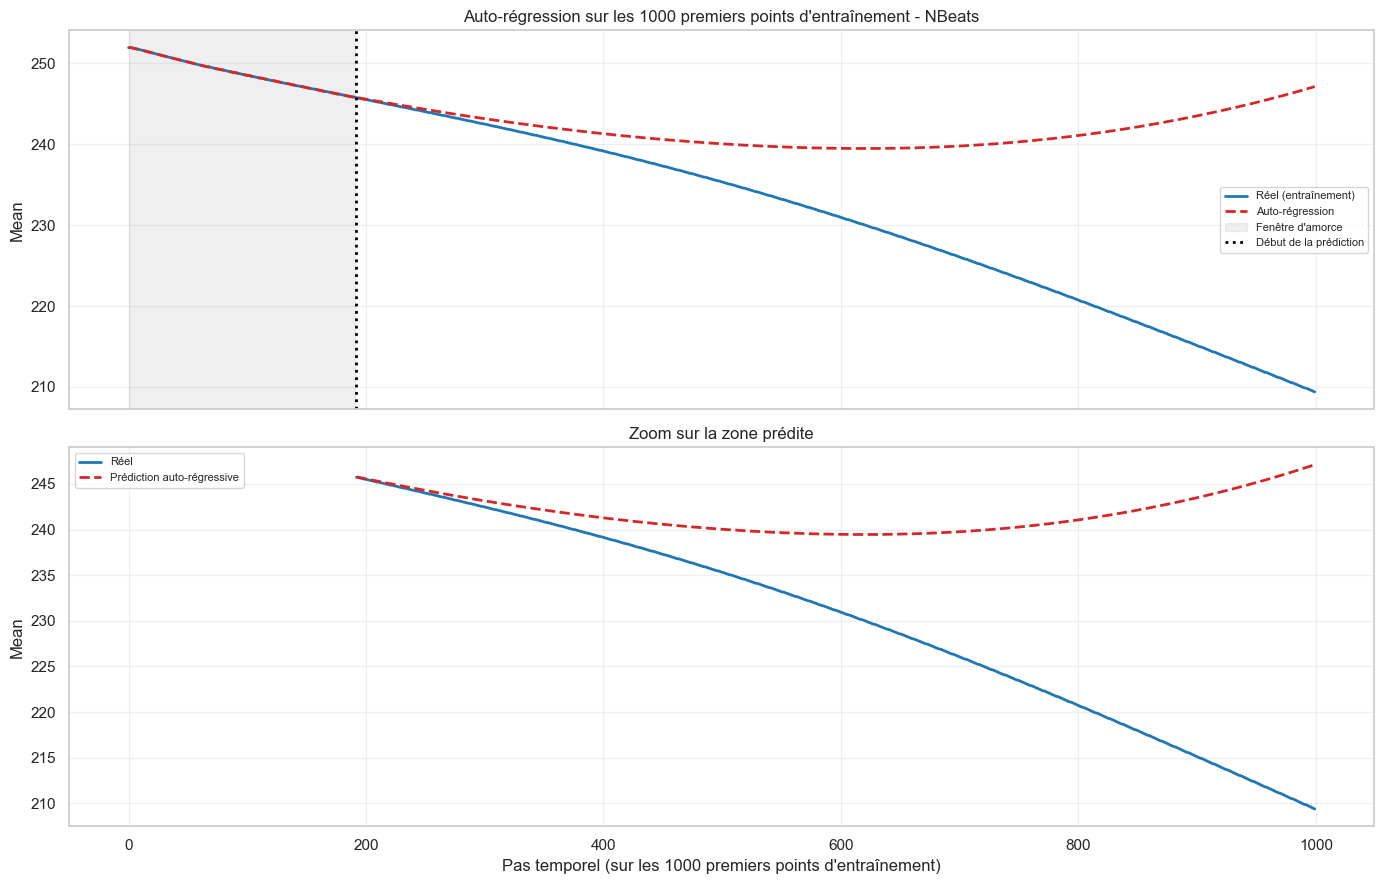

Modèle utilisé: NBeats
Points analysés: 1000
Longueur d'amorce réelle: 192
Longueur prédite: 808
MAE sur la partie prédite: 11.9280
RMSE sur la partie prédite: 16.3064


In [14]:
# === AUTO-RÉGRESSION SUR LES 1000 PREMIERS POINTS D'ENTRAÎNEMENT ===
# Cette cellule prend les 1000 premiers points utilisés pour l'entraînement,
# fait une prédiction auto-régressive à partir de la fenêtre initiale,
# puis compare la série réelle et la série prédite.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun modèle entraîné trouvé. Exécute d'abord la cellule d'entraînement des modèles.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'train_frame' not in globals() or 'target_scaler' not in globals() or 'freq_target_col' not in globals():
    raise RuntimeError("Variables d'entraînement manquantes. Exécute d'abord la préparation des données.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

train_scaled = np.asarray(
    train_y if 'train_y' in globals() else target_scaler.transform(train_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)

n_points = min(1000, len(train_scaled))
if n_points < SEQ_INPUT_LEN + 1:
    raise RuntimeError(f"Pas assez de points d'entraînement pour lancer l'auto-régression (n_points={n_points}, SEQ_INPUT_LEN={SEQ_INPUT_LEN}).")

segment_scaled = train_scaled[:n_points]
segment_values = pd.to_numeric(train_frame[freq_target_col].iloc[:n_points], errors='coerce').values.astype(float)

def predict_next_step(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        full_pred = model(x_tensor).detach().cpu().numpy().reshape(-1)
    return float(full_pred[0])

# Séquence prédite: les SEQ_INPUT_LEN premiers points servent d'amorçage réel,
# puis chaque nouveau point est prédit à partir des valeurs précédentes.
pred_scaled = segment_scaled[:SEQ_INPUT_LEN].tolist()
history = segment_scaled[:SEQ_INPUT_LEN].tolist()
for _ in range(SEQ_INPUT_LEN, n_points):
    next_pred = predict_next_step(best_model, history[-SEQ_INPUT_LEN:])
    pred_scaled.append(next_pred)
    history.append(next_pred)

pred_scaled = np.asarray(pred_scaled, dtype=np.float32)
pred_values = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
true_values = target_scaler.inverse_transform(segment_scaled.reshape(-1, 1)).reshape(-1)

# Métriques uniquement sur la partie prédite (après la fenêtre d'amorçage)
future_true = true_values[SEQ_INPUT_LEN:]
future_pred = pred_values[SEQ_INPUT_LEN:]

ar_mae = mean_absolute_error(future_true, future_pred)
ar_rmse = float(np.sqrt(mean_squared_error(future_true, future_pred)))
ar_r2 = r2_score(future_true, future_pred) if len(future_true) > 1 else np.nan

summary_ar_train = pd.DataFrame([
    {
        'model': best_model_name,
        'n_points': n_points,
        'seed_length': SEQ_INPUT_LEN,
        'predicted_length': n_points - SEQ_INPUT_LEN,
        'MAE': ar_mae,
        'RMSE': ar_rmse,
        'R2': ar_r2,
    }
])

display(summary_ar_train)

comparison_ar_train_df = pd.DataFrame({
    'step': np.arange(n_points),
    'truth': true_values,
    'predicted': pred_values,
})
comparison_ar_train_df['residual'] = comparison_ar_train_df['truth'] - comparison_ar_train_df['predicted']
# Affiche les 5 points réels avant la bascule et les 15 premiers points générés
display(comparison_ar_train_df.iloc[SEQ_INPUT_LEN - 5 : SEQ_INPUT_LEN + 15])
display(comparison_ar_train_df.head(10))
display(comparison_ar_train_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(comparison_ar_train_df['step'], comparison_ar_train_df['truth'], color='tab:blue', linewidth=2, label='Réel (entraînement)')
ax.plot(comparison_ar_train_df['step'], comparison_ar_train_df['predicted'], color='tab:red', linewidth=2, linestyle='--', label='Auto-régression')
ax.axvspan(0, SEQ_INPUT_LEN - 1, color='tab:gray', alpha=0.12, label='Fenêtre d\'amorce')
ax.axvline(SEQ_INPUT_LEN - 0.5, color='black', linestyle=':', linewidth=2, label='Début de la prédiction')
ax.set_title(f"Auto-régression sur les {n_points} premiers points d'entraînement - {best_model_name}")
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(comparison_ar_train_df['step'][SEQ_INPUT_LEN:], comparison_ar_train_df['truth'][SEQ_INPUT_LEN:], color='tab:blue', linewidth=2, label='Réel')
ax.plot(comparison_ar_train_df['step'][SEQ_INPUT_LEN:], comparison_ar_train_df['predicted'][SEQ_INPUT_LEN:], color='tab:red', linewidth=2, linestyle='--', label='Prédiction auto-régressive')
ax.set_xlabel('Pas temporel (sur les 1000 premiers points d\'entraînement)')
ax.set_ylabel(freq_target_col)
ax.set_title('Zoom sur la zone prédite')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Points analysés: {n_points}")
print(f"Longueur d'amorce réelle: {SEQ_INPUT_LEN}")
print(f"Longueur prédite: {n_points - SEQ_INPUT_LEN}")
print(f"MAE sur la partie prédite: {ar_mae:.4f}")
print(f"RMSE sur la partie prédite: {ar_rmse:.4f}")

,model,n_points,seed_length,predicted_length,MAE,RMSE,R2
0,NBeats,1000,192,808,0.534305,0.625228,0.996663


,step,truth,predicted,residual
187,187,198.485046,198.485046,0.000000
188,188,198.422180,198.422180,0.000000
189,189,198.390640,198.390640,0.000000
190,190,198.359100,198.359100,0.000000
191,191,198.295761,198.295761,0.000000
192,192,198.232483,198.139908,0.092575
193,193,198.169189,198.082306,0.086884
194,194,198.105591,198.024246,0.081345
195,195,198.041992,197.965378,0.076614
196,196,197.979187,197.907486,0.071701


,step,truth,predicted,residual
0,0,209.333466,209.333466,0.0
1,1,209.269684,209.269684,0.0
2,2,209.237762,209.237762,0.0
3,3,209.205856,209.205856,0.0
4,4,209.141846,209.141846,0.0
5,5,209.077866,209.077866,0.0
6,6,209.013977,209.013977,0.0
7,7,208.949692,208.949692,0.0
8,8,208.885452,208.885452,0.0
9,9,208.821579,208.821579,0.0


,step,truth,predicted,residual
990,990,161.652161,162.977997,-1.325836
991,991,161.621124,162.955429,-1.334305
992,992,161.605606,162.932953,-1.327347
993,993,161.590103,162.910538,-1.320435
994,994,161.559113,162.888214,-1.329102
995,995,161.528168,162.865982,-1.337814
996,996,161.497223,162.843811,-1.346588
997,997,161.466446,162.821686,-1.355240
998,998,161.435699,162.799622,-1.363922
999,999,161.405258,162.777603,-1.372345


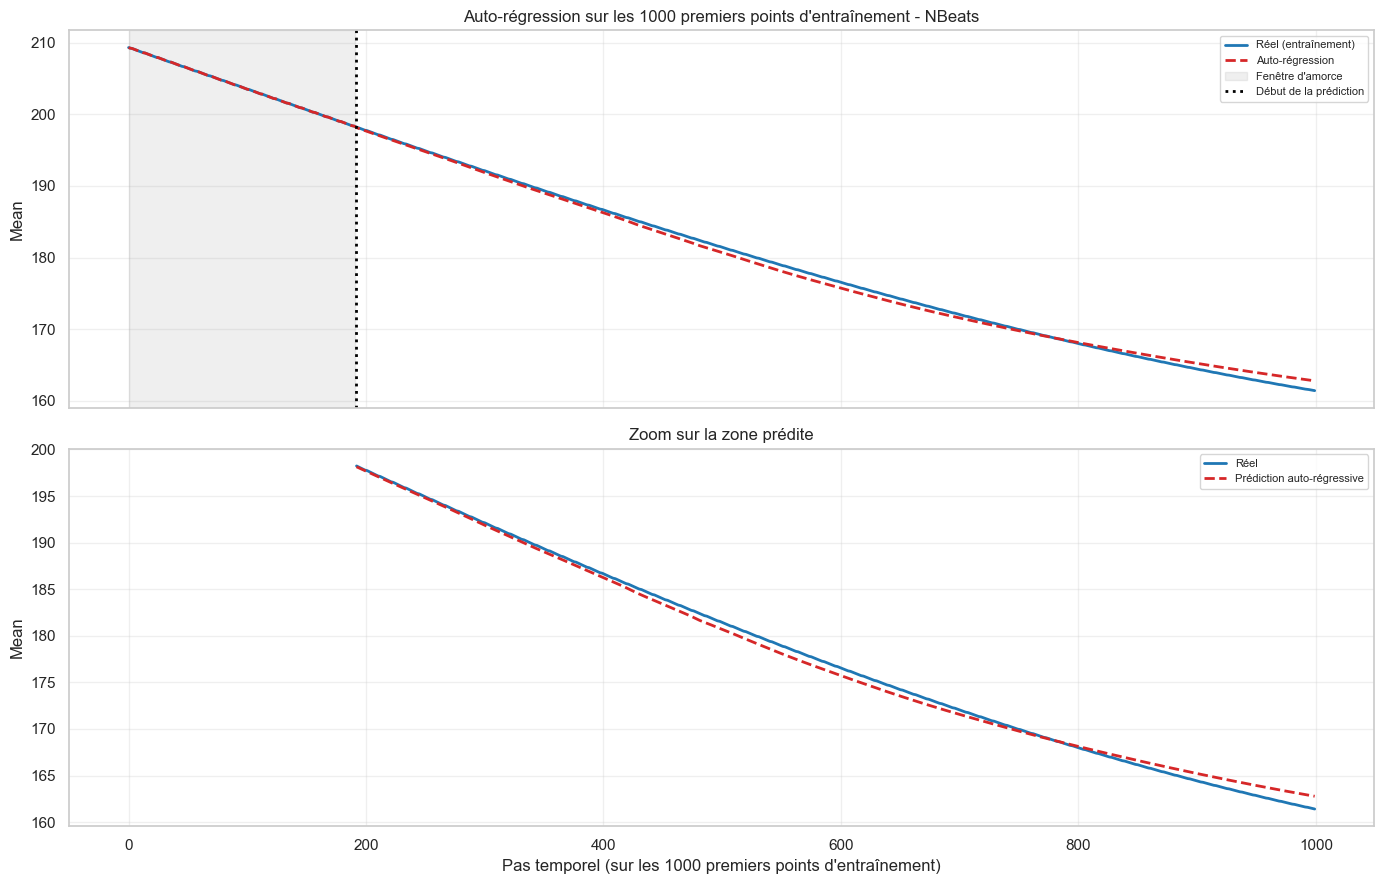

Modèle utilisé: NBeats
Points analysés: 1000
Longueur d'amorce réelle: 192
Longueur prédite: 808
MAE sur la partie prédite: 0.5343
RMSE sur la partie prédite: 0.6252


In [ ]:
# === AUTO-RÉGRESSION SUR LES 1000 PREMIERS POINTS D'ENTRAÎNEMENT ===
# Cette cellule prend les 1000 premiers points utilisés pour l'entraînement,
# fait une prédiction auto-régressive à partir de la fenêtre initiale,
# puis compare la série réelle et la série prédite.

if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Aucun modèle entraîné trouvé. Exécute d'abord la cellule d'entraînement des modèles.")
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError("trained_models est vide. Exécute d'abord l'entraînement des modèles.")
if 'train_frame' not in globals() or 'target_scaler' not in globals() or 'freq_target_col' not in globals():
    raise RuntimeError("Variables d'entraînement manquantes. Exécute d'abord la préparation des données.")

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name].to(device)
best_model.eval()

train_scaled = np.asarray(
    train_y if 'train_y' in globals() else target_scaler.transform(train_frame[[freq_target_col]]),
    dtype=np.float32,
).reshape(-1)
# Au lieu de prendre les 1000 premiers points, on définit les bornes
start_idx = 1000
end_idx = 2000

# On vérifie qu'on a assez de données dans le dataset
end_idx = min(end_idx, len(train_scaled))
n_points = end_idx - start_idx # Sera égal à 1000 si le dataset est assez grand

if n_points < SEQ_INPUT_LEN + 1:
    raise RuntimeError(f"Pas assez de points d'entraînement pour lancer l'auto-régression (n_points={n_points}, SEQ_INPUT_LEN={SEQ_INPUT_LEN}).")

# MODIFICATION DU SLICING ICI : [start_idx : end_idx]
segment_scaled = train_scaled[start_idx:end_idx]
segment_values = pd.to_numeric(train_frame[freq_target_col].iloc[start_idx:end_idx], errors='coerce').values.astype(float)
def predict_next_step(model, window_scaled):
    x_tensor = torch.tensor(np.asarray(window_scaled, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        full_pred = model(x_tensor).detach().cpu().numpy().reshape(-1)
    return float(full_pred[0])

# Séquence prédite: les SEQ_INPUT_LEN premiers points servent d'amorçage réel,
# puis chaque nouveau point est prédit à partir des valeurs précédentes.
pred_scaled = segment_scaled[:SEQ_INPUT_LEN].tolist()
history = segment_scaled[:SEQ_INPUT_LEN].tolist()
for _ in range(SEQ_INPUT_LEN, n_points):
    next_pred = predict_next_step(best_model, history[-SEQ_INPUT_LEN:])
    pred_scaled.append(next_pred)
    history.append(next_pred)

pred_scaled = np.asarray(pred_scaled, dtype=np.float32)
pred_values = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
true_values = target_scaler.inverse_transform(segment_scaled.reshape(-1, 1)).reshape(-1)

# Métriques uniquement sur la partie prédite (après la fenêtre d'amorçage)
future_true = true_values[SEQ_INPUT_LEN:]
future_pred = pred_values[SEQ_INPUT_LEN:]

ar_mae = mean_absolute_error(future_true, future_pred)
ar_rmse = float(np.sqrt(mean_squared_error(future_true, future_pred)))
ar_r2 = r2_score(future_true, future_pred) if len(future_true) > 1 else np.nan

summary_ar_train = pd.DataFrame([
    {
        'model': best_model_name,
        'n_points': n_points,
        'seed_length': SEQ_INPUT_LEN,
        'predicted_length': n_points - SEQ_INPUT_LEN,
        'MAE': ar_mae,
        'RMSE': ar_rmse,
        'R2': ar_r2,
    }
])

display(summary_ar_train)

comparison_ar_train_df = pd.DataFrame({
    'step': np.arange(n_points),
    'truth': true_values,
    'predicted': pred_values,
})
comparison_ar_train_df['residual'] = comparison_ar_train_df['truth'] - comparison_ar_train_df['predicted']
# Affiche les 5 points réels avant la bascule et les 15 premiers points générés
display(comparison_ar_train_df.iloc[SEQ_INPUT_LEN - 5 : SEQ_INPUT_LEN + 15])
display(comparison_ar_train_df.head(10))
display(comparison_ar_train_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(comparison_ar_train_df['step'], comparison_ar_train_df['truth'], color='tab:blue', linewidth=2, label='Réel (entraînement)')
ax.plot(comparison_ar_train_df['step'], comparison_ar_train_df['predicted'], color='tab:red', linewidth=2, linestyle='--', label='Auto-régression')
ax.axvspan(0, SEQ_INPUT_LEN - 1, color='tab:gray', alpha=0.12, label='Fenêtre d\'amorce')
ax.axvline(SEQ_INPUT_LEN - 0.5, color='black', linestyle=':', linewidth=2, label='Début de la prédiction')
ax.set_title(f"Auto-régression sur les {n_points} premiers points d'entraînement - {best_model_name}")
ax.set_ylabel(freq_target_col)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(comparison_ar_train_df['step'][SEQ_INPUT_LEN:], comparison_ar_train_df['truth'][SEQ_INPUT_LEN:], color='tab:blue', linewidth=2, label='Réel')
ax.plot(comparison_ar_train_df['step'][SEQ_INPUT_LEN:], comparison_ar_train_df['predicted'][SEQ_INPUT_LEN:], color='tab:red', linewidth=2, linestyle='--', label='Prédiction auto-régressive')
ax.set_xlabel('Pas temporel (sur les 1000 premiers points d\'entraînement)')
ax.set_ylabel(freq_target_col)
ax.set_title('Zoom sur la zone prédite')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Modèle utilisé: {best_model_name}")
print(f"Points analysés: {n_points}")
print(f"Longueur d'amorce réelle: {SEQ_INPUT_LEN}")
print(f"Longueur prédite: {n_points - SEQ_INPUT_LEN}")
print(f"MAE sur la partie prédite: {ar_mae:.4f}")
print(f"RMSE sur la partie prédite: {ar_rmse:.4f}")

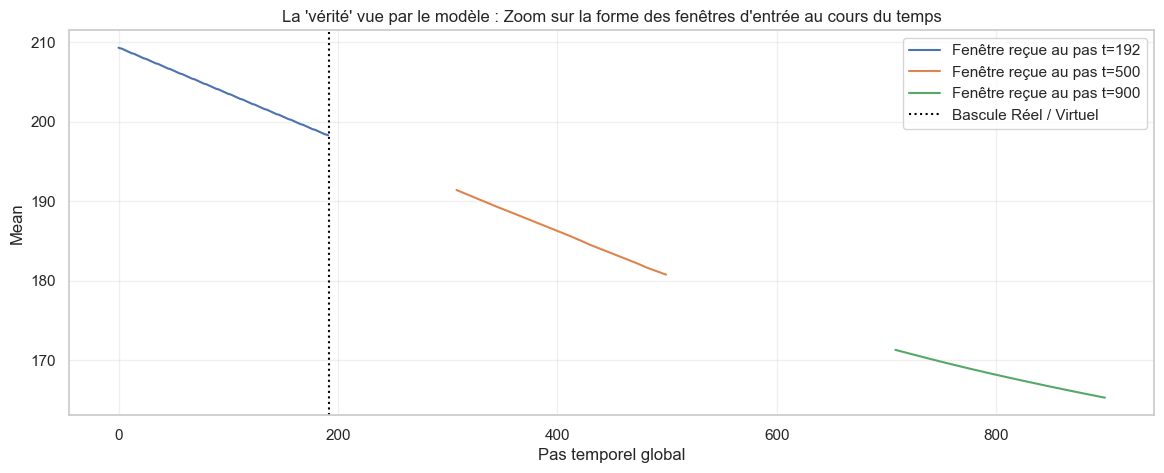

In [16]:
import matplotlib.pyplot as plt

# Choisissons 3 moments clés de ton auto-régression sur les 1000 points
# (Index 192 = début absolu, Index 500 = milieu, Index 900 = fin)
moments_cles = [SEQ_INPUT_LEN, 500, 900]

plt.figure(figsize=(14, 5))

for idx in moments_cles:
    # 1. On extrait la fenêtre de 192 points que le modèle a REÇUE à ce pas de temps
    fenetre_scaled = np.array(pred_scaled[idx - SEQ_INPUT_LEN : idx])
    
    # 2. On la remet à l'échelle d'origine pour qu'elle soit lisible (comme tes graphiques)
    fenetre_values = target_scaler.inverse_transform(fenetre_scaled.reshape(-1, 1)).reshape(-1)
    
    # 3. On trace cette sous-courbe
    temps_relatif = np.arange(idx - SEQ_INPUT_LEN, idx)
    plt.plot(temps_relatif, fenetre_values, label=f"Fenêtre reçue au pas t={idx}")

plt.axvline(SEQ_INPUT_LEN - 0.5, color='black', linestyle=':', label='Bascule Réel / Virtuel')
plt.title("La 'vérité' vue par le modèle : Zoom sur la forme des fenêtres d'entrée au cours du temps")
plt.xlabel("Pas temporel global")
plt.ylabel(freq_target_col)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import re


def _sanitize_model_name(model_name):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(model_name)).strip('_') or 'model'


def _save_model_weights(models_dict, output_dir, proxy_name):
    if not isinstance(models_dict, dict) or len(models_dict) == 0:
        print(f"Aucun modèle à sauvegarder pour le proxy {proxy_name}.")
        return []

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for model_name, model in models_dict.items():
        if not hasattr(model, 'state_dict'):
            print(f"Modèle ignoré (pas de state_dict): {model_name}")
            continue

        file_path = output_dir / f"proxy_{_sanitize_model_name(proxy_name)}_{_sanitize_model_name(model_name)}.pth"
        torch.save(
            {
                'model_name': model_name,
                'model_type': type(model).__name__,
                'proxy_name': proxy_name,
                'state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
            },
            file_path,
        )
        saved_paths.append(file_path)

    if saved_paths:
        print(f"{len(saved_paths)} fichier(s) de poids sauvegardé(s) pour le proxy {proxy_name} dans {output_dir}")
        for path in saved_paths:
            print(f"- {path}")
    return saved_paths


weights_root = Path('model_weights')
saved_weight_files = []

if 'trained_models' in globals():
    saved_weight_files += _save_model_weights(trained_models, weights_root / 'frequency', 'frequency')

if 'intensity_trained_models' in globals():
    saved_weight_files += _save_model_weights(intensity_trained_models, weights_root / 'intensity', 'intensity')

if not saved_weight_files:
    print("Aucun dictionnaire de modèles entraînés n'a été trouvé dans l'environnement courant.")